<a href="https://colab.research.google.com/github/UjjwalCoderDTU/SatQuery/blob/main/Qwen_RGB_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )
else:
    raise RuntimeError("❌ GPU is not available. Select T4 GPU first.")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB


In [8]:
!pip install -q -U transformers accelerate peft bitsandbytes qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 26.1 MB/s eta 0:00:00


In [15]:
import os

MYDRIVE = "/content/drive/MyDrive"

print("MyDrive exists:", os.path.exists(MYDRIVE))

print("\nTop-level contents:")
for item in sorted(os.listdir(MYDRIVE)):
    print(" -", item)

MyDrive exists: True

Top-level contents:
 - Colab Notebooks
 - SatQuery


In [16]:
import os

# ============================================================
# FINAL PROJECT ROOT
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/finalProject"

# Dataset
DATASET_DIR = os.path.join(
    PROJECT_ROOT,
    "BigEarthNet_4508"
)

# Images
RGB_DIR = os.path.join(
    DATASET_DIR,
    "images",
    "rgb"
)

MS_DIR = os.path.join(
    DATASET_DIR,
    "images",
    "multispectral"
)

# Dataset files
TRAIN_JSONL = os.path.join(
    DATASET_DIR,
    "train.jsonl"
)

VAL_JSONL = os.path.join(
    DATASET_DIR,
    "val.jsonl"
)

VQA_TRAIN_JSONL = os.path.join(
    DATASET_DIR,
    "vqa_train.jsonl"
)

VQA_VAL_JSONL = os.path.join(
    DATASET_DIR,
    "vqa_val.jsonl"
)

QWEN_TRAIN_JSONL = os.path.join(
    DATASET_DIR,
    "qwen_train.jsonl"
)

QWEN_VAL_JSONL = os.path.join(
    DATASET_DIR,
    "qwen_val.jsonl"
)

# Review
REVIEW_DIR = os.path.join(
    DATASET_DIR,
    "dataset_review"
)

# Training checkpoints
CHECKPOINT_DIR = os.path.join(
    PROJECT_ROOT,
    "qwen_lora_checkpoints"
)

# Final trained adapter
FINAL_MODEL_DIR = os.path.join(
    PROJECT_ROOT,
    "final_qwen_lora"
)

# Logs
LOG_DIR = os.path.join(
    PROJECT_ROOT,
    "training_logs"
)

# Create everything
for directory in [
    PROJECT_ROOT,
    DATASET_DIR,
    RGB_DIR,
    MS_DIR,
    REVIEW_DIR,
    CHECKPOINT_DIR,
    FINAL_MODEL_DIR,
    LOG_DIR
]:
    os.makedirs(directory, exist_ok=True)

print("=" * 70)
print("FINAL PROJECT DIRECTORY")
print("=" * 70)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATASET_DIR  :", DATASET_DIR)
print("RGB_DIR      :", RGB_DIR)
print("MS_DIR       :", MS_DIR)
print("CHECKPOINTS  :", CHECKPOINT_DIR)
print("FINAL MODEL  :", FINAL_MODEL_DIR)
print("LOG DIR      :", LOG_DIR)

FINAL PROJECT DIRECTORY
PROJECT_ROOT : /content/drive/MyDrive/finalProject
DATASET_DIR  : /content/drive/MyDrive/finalProject/BigEarthNet_4508
RGB_DIR      : /content/drive/MyDrive/finalProject/BigEarthNet_4508/images/rgb
MS_DIR       : /content/drive/MyDrive/finalProject/BigEarthNet_4508/images/multispectral
CHECKPOINTS  : /content/drive/MyDrive/finalProject/qwen_lora_checkpoints
FINAL MODEL  : /content/drive/MyDrive/finalProject/final_qwen_lora
LOG DIR      : /content/drive/MyDrive/finalProject/training_logs


In [17]:
!pip -q install \
    huggingface_hub \
    datasets \
    pandas \
    pyarrow \
    numpy \
    pillow \
    lmdb \
    safetensors \
    tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.8/346.8 kB 11.0 MB/s eta 0:00:00


In [18]:
from huggingface_hub import hf_hub_download
import pandas as pd
import os

BEN_TXT_REPO = "BIFOLD-BigEarthNetv2-0/BigEarthNet.txt"

print("Downloading BigEarthNet annotation metadata...")

metadata_path = hf_hub_download(
    repo_id=BEN_TXT_REPO,
    repo_type="dataset",
    filename="BigEarthNet.txt.parquet"
)

print("✅ Metadata downloaded")
print("Path:", metadata_path)

print(
    "Size:",
    round(os.path.getsize(metadata_path) / 1024**2, 2),
    "MB"
)

BigEarthNet.txt.parquet: reconstructing file:   0%|          |  0.00B /  467MB            

BigEarthNet.txt.parquet: downloading bytes:           |  0.00B            

✅ Metadata downloaded
Path: /root/.cache/huggingface/hub/datasets--BIFOLD-BigEarthNetv2-0--BigEarthNet.txt/snapshots/72d865f2146f0a85b720f7f3ca1cdbaeafc3d316/BigEarthNet.txt.parquet
Size: 445.19 MB


In [19]:
df_txt = pd.read_parquet(metadata_path)

print("Shape:", df_txt.shape)

print("\nColumns:")
print(df_txt.columns.tolist())

print("\nFirst 3 rows:")
display(df_txt.head(3))

Shape: (9553962, 13)

Columns:
['ID', 's1_name', 'patch_id', 'input', 'output', 'type', 'category', 'split', 'latitude', 'longitude', 'country', 'season', 'climate_zone']

First 3 rows:


,ID,s1_name,patch_id,input,output,type,category,split,latitude,longitude,country,season,climate_zone
0,1,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_26_57,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,Would you say that any arable land lies next t...,yes,binary,adjacency,test,48.110035,12.7403,Austria,Summer,"Cold, no dry season, warm summer"
1,2,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_26_57,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,Would you confirm that any broad-leaved forest...,no,binary,adjacency,test,48.110035,12.7403,Austria,Summer,"Cold, no dry season, warm summer"
2,3,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_26_57,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,Do pastures cover between 864000 square meters...,no,binary,area,test,48.110035,12.7403,Austria,Summer,"Cold, no dry season, warm summer"


In [20]:
print("Annotation types:")
print(df_txt["type"].value_counts())

print("\nAnnotation categories:")
print(
    df_txt["category"]
    .value_counts()
    .head(30)
)

Annotation types:
type
binary          3625160
mcq             3259184
bounding box    2205686
captioning       463932
Name: count, dtype: int64

Annotation categories:
category
presence        1391053
area            1390845
count           1390730
adjacency       1222128
point           1143883
reference       1061803
None             463932
season           463662
climate zone     463637
country          463274
relative pos      99015
Name: count, dtype: int64


In [21]:
SUBSET_REPO = (
    "hackelle/BigEarthNetV2-Lithuania-Summer-LMDB"
)

subset_metadata_path = hf_hub_download(
    repo_id=SUBSET_REPO,
    repo_type="dataset",
    filename="metadata_lithuania_summer.parquet"
)

subset_df = pd.read_parquet(
    subset_metadata_path
)

print("Subset shape:", subset_df.shape)

print("\nColumns:")
print(subset_df.columns.tolist())

display(subset_df.head(3))

metadata_lithuania_summer.parquet: reconstructing file:   0%|          |  0.00B /  253kB            

metadata_lithuania_summer.parquet: downloading bytes:           |  0.00B            

Subset shape: (8775, 8)

Columns:
['patch_id', 'labels', 'split', 'country', 's1_name', 's2v1_name', 'contains_seasonal_snow', 'contains_cloud_or_shadow']


,patch_id,labels,split,country,s1_name,s2v1_name,contains_seasonal_snow,contains_cloud_or_shadow
39329,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,[Marine waters],test,Lithuania,S1B_IW_GRDH_1SDV_20170719T045054_34UDG_61_54,S2A_MSIL2A_20170720T100031_61_54,False,False
39330,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,[Marine waters],test,Lithuania,S1B_IW_GRDH_1SDV_20170719T045054_34UDG_61_55,S2A_MSIL2A_20170720T100031_61_55,False,False
39331,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,[Marine waters],test,Lithuania,S1B_IW_GRDH_1SDV_20170719T045054_34UDG_61_56,S2A_MSIL2A_20170720T100031_61_56,False,False


In [22]:
txt_patch_ids = set(
    df_txt["patch_id"]
    .dropna()
    .unique()
)

image_patch_ids = set(
    subset_df["patch_id"]
    .dropna()
    .unique()
)

common_ids = (
    txt_patch_ids
    .intersection(image_patch_ids)
)

print(
    "BigEarthNet annotation patches:",
    len(txt_patch_ids)
)

print(
    "Image subset patches:",
    len(image_patch_ids)
)

print(
    "Common patches:",
    len(common_ids)
)

BigEarthNet annotation patches: 464044
Image subset patches: 8775
Common patches: 8363


In [23]:
df_common = df_txt[
    df_txt["patch_id"].isin(common_ids)
].copy()

print(
    "Rows after image pairing:",
    len(df_common)
)

print(
    "Unique patches:",
    df_common["patch_id"].nunique()
)

print("\nAnnotation types:")
print(
    df_common["type"].value_counts()
)

Rows after image pairing: 185443
Unique patches: 8363

Annotation types:
type
binary          65454
mcq             60130
bounding box    51497
captioning       8362
Name: count, dtype: int64


In [24]:
preferred_types = [
    "mcq",
    "binary",
    "captioning"
]

preferred_categories = [
    "Area",
    "Counting",
    "Adjacency",
    "Relative Position",
    "Presence",
    "Country",
    "Season",
    "Climate Zone"
]

complex_df = df_common[
    df_common["type"].isin(preferred_types)
    |
    df_common["category"].isin(preferred_categories)
].copy()

print(
    "Complex annotation rows:",
    len(complex_df)
)

print(
    "Unique patches:",
    complex_df["patch_id"].nunique()
)

print("\nTypes:")
print(
    complex_df["type"].value_counts()
)

print("\nCategories:")
print(
    complex_df["category"]
    .value_counts()
    .head(20)
)

Complex annotation rows: 133946
Unique patches: 8363

Types:
type
binary        65454
mcq           60130
captioning     8362
Name: count, dtype: int64

Categories:
category
count           25075
presence        25071
area            25070
adjacency       22239
None             8362
country          8360
season           8359
climate zone     8355
relative pos     3055
Name: count, dtype: int64


In [25]:
TARGET_PATCHES = 5000

available_patch_ids = (
    complex_df["patch_id"]
    .drop_duplicates()
    .sample(
        frac=1,
        random_state=42
    )
    .tolist()
)

if len(available_patch_ids) < TARGET_PATCHES:
    raise RuntimeError(
        f"Only {len(available_patch_ids)} patches available. "
        f"Cannot select {TARGET_PATCHES}."
    )

selected_patch_ids = (
    available_patch_ids[:TARGET_PATCHES]
)

print(
    "Selected unique patches:",
    len(selected_patch_ids)
)

print("\nFirst 10:")

for patch_id in selected_patch_ids[:10]:
    print(patch_id)

Selected unique patches: 5000

First 10:
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_30_67
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_64_44
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_80_68
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_57_39
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_65_19
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_11_43
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_02_15
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_73_09
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_06_87
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_34_26


In [26]:
selected_annotations = complex_df[
    complex_df["patch_id"].isin(
        selected_patch_ids
    )
].copy()

print(
    "Selected annotation rows:",
    len(selected_annotations)
)

print(
    "Unique selected patches:",
    selected_annotations["patch_id"].nunique()
)

assert (
    selected_annotations["patch_id"].nunique()
    == TARGET_PATCHES
)

print(
    "✅ Exactly",
    TARGET_PATCHES,
    "unique patches selected"
)

Selected annotation rows: 80092
Unique selected patches: 5000
✅ Exactly 5000 unique patches selected


In [27]:
!pip -q install lmdb safetensors pillow tqdm

In [28]:
from huggingface_hub import hf_hub_download
import os

print("Downloading satellite image LMDB...")

lmdb_data_path = hf_hub_download(
    repo_id=SUBSET_REPO,
    repo_type="dataset",
    filename="BENv2_lithuania_summer.lmdb/data.mdb"
)

print("✅ LMDB downloaded")

print("Path:", lmdb_data_path)

print(
    "Size:",
    round(
        os.path.getsize(lmdb_data_path)
        / 1024**3,
        2
    ),
    "GB"
)

BENv2_lithuania_summer.lmdb/data.mdb: reconstructing file:   0%|          |  0.00B / 2.48GB            

BENv2_lithuania_summer.lmdb/data.mdb: downloading bytes:           |  0.00B            

✅ LMDB downloaded
Path: /root/.cache/huggingface/hub/datasets--hackelle--BigEarthNetV2-Lithuania-Summer-LMDB/snapshots/7a83ae701109ec232d40665b9677fc46310a1a8b/BENv2_lithuania_summer.lmdb/data.mdb
Size: 2.31 GB


In [29]:
import os
import shutil

LMDB_DIR = "/content/BENv2_lithuania_summer.lmdb"

os.makedirs(
    LMDB_DIR,
    exist_ok=True
)

target_data = os.path.join(
    LMDB_DIR,
    "data.mdb"
)

if not os.path.exists(target_data):

    shutil.copy2(
        lmdb_data_path,
        target_data
    )

print("LMDB:", LMDB_DIR)

print(
    "data.mdb exists:",
    os.path.exists(target_data)
)

print(
    "Size:",
    round(
        os.path.getsize(target_data)
        / 1024**3,
        2
    ),
    "GB"
)

LMDB: /content/BENv2_lithuania_summer.lmdb
data.mdb exists: True
Size: 2.31 GB


In [30]:
import lmdb

env = lmdb.open(
    LMDB_DIR,
    readonly=True,
    lock=False,
    readahead=False,
    max_readers=126
)

print("✅ LMDB opened successfully")

✅ LMDB opened successfully


In [31]:
test_patch_id = selected_patch_ids[0]

with env.begin(
    write=False
) as txn:

    raw = txn.get(
        test_patch_id.encode()
    )

if raw is None:
    raise RuntimeError(
        "❌ Test patch was not found in LMDB"
    )

print("✅ Test patch found")
print("Patch:", test_patch_id)
print("Raw bytes:", len(raw))

✅ Test patch found
Patch: S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_30_67
Raw bytes: 160832


In [32]:
from safetensors.numpy import load as safetensor_load

tensor = safetensor_load(raw)

print("Available bands:")
print(list(tensor.keys()))

Available bands:
['B01', 'B06', 'B08', 'B09', 'B8A', 'B04', 'B07', 'B12', 'B03', 'B11', 'B02', 'B05']


In [33]:
for band in sorted(tensor.keys()):

    print(
        band,
        "| shape =", tensor[band].shape,
        "| dtype =", tensor[band].dtype,
        "| min =", tensor[band].min(),
        "| max =", tensor[band].max()
    )

B01 | shape = (20, 20) | dtype = uint16 | min = 100 | max = 466
B02 | shape = (120, 120) | dtype = uint16 | min = 101 | max = 1036
B03 | shape = (120, 120) | dtype = uint16 | min = 134 | max = 1224
B04 | shape = (120, 120) | dtype = uint16 | min = 93 | max = 1444
B05 | shape = (60, 60) | dtype = uint16 | min = 337 | max = 1857
B06 | shape = (60, 60) | dtype = uint16 | min = 1020 | max = 3521
B07 | shape = (60, 60) | dtype = uint16 | min = 1153 | max = 4279
B08 | shape = (120, 120) | dtype = uint16 | min = 922 | max = 4936
B09 | shape = (20, 20) | dtype = uint16 | min = 1692 | max = 3900
B11 | shape = (60, 60) | dtype = uint16 | min = 707 | max = 3137
B12 | shape = (60, 60) | dtype = uint16 | min = 363 | max = 2483
B8A | shape = (60, 60) | dtype = uint16 | min = 1322 | max = 4607


In [34]:
import numpy as np
from PIL import Image

S2_BANDS = [
    "B01",
    "B02",
    "B03",
    "B04",
    "B05",
    "B06",
    "B07",
    "B08",
    "B8A",
    "B09",
    "B11",
    "B12"
]

TARGET_SIZE = (120, 120)

In [35]:
def normalize_band_for_rgb(x):

    x = x.astype(
        np.float32
    )

    low = np.percentile(
        x,
        2
    )

    high = np.percentile(
        x,
        98
    )

    if high <= low:
        return np.zeros_like(
            x,
            dtype=np.uint8
        )

    x = (
        x - low
    ) / (
        high - low
    )

    x = np.clip(
        x,
        0,
        1
    )

    return (
        x * 255
    ).astype(
        np.uint8
    )


def make_rgb(tensor):

    R = normalize_band_for_rgb(
        tensor["B04"]
    )

    G = normalize_band_for_rgb(
        tensor["B03"]
    )

    B = normalize_band_for_rgb(
        tensor["B02"]
    )

    return np.stack(
        [R, G, B],
        axis=-1
    )

In [36]:
def resize_band(
    band,
    target_size=TARGET_SIZE
):

    img = Image.fromarray(
        band.astype(np.float32),
        mode="F"
    )

    img = img.resize(
        target_size,
        resample=Image.Resampling.BILINEAR
    )

    return np.asarray(
        img,
        dtype=np.float32
    )

RGB:
Shape: (120, 120, 3)
dtype: uint8

Multispectral:
Shape: (12, 120, 120)
dtype: float32


/tmp/ipykernel_1712/300452339.py:6: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(


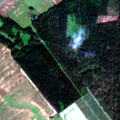

In [37]:
rgb = make_rgb(tensor)

resized_bands = [
    resize_band(
        tensor[band]
    )
    for band in S2_BANDS
]

ms = np.stack(
    resized_bands,
    axis=0
).astype(np.float32)

print("RGB:")
print("Shape:", rgb.shape)
print("dtype:", rgb.dtype)

print("\nMultispectral:")
print("Shape:", ms.shape)
print("dtype:", ms.dtype)

display(
    Image.fromarray(rgb)
)

In [38]:
test_rgb_path = os.path.join(
    RGB_DIR,
    f"{test_patch_id}.png"
)

test_ms_path = os.path.join(
    MS_DIR,
    f"{test_patch_id}.npz"
)

Image.fromarray(
    rgb
).save(
    test_rgb_path
)

np.savez_compressed(
    test_ms_path,
    data=ms,
    bands=np.array(S2_BANDS),
    patch_id=np.array(test_patch_id)
)

print("RGB saved:", test_rgb_path)
print("MS saved :", test_ms_path)

print(
    "\nRGB exists:",
    os.path.exists(test_rgb_path)
)

print(
    "MS exists:",
    os.path.exists(test_ms_path)
)

RGB saved: /content/drive/MyDrive/finalProject/BigEarthNet_4508/images/rgb/S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_30_67.png
MS saved : /content/drive/MyDrive/finalProject/BigEarthNet_4508/images/multispectral/S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_30_67.npz

RGB exists: True
MS exists: True


In [40]:
import random

random.seed(42)

common_split_df = subset_df[
    subset_df["patch_id"].isin(
        common_ids
    )
].copy()

train_ids = (
    common_split_df[
        common_split_df["split"] == "train"
    ]["patch_id"]
    .dropna()
    .unique()
    .tolist()
)

val_ids = (
    common_split_df[
        common_split_df["split"] == "validation"
    ]["patch_id"]
    .dropna()
    .unique()
    .tolist()
)

print(
    "Available training patches:",
    len(train_ids)
)

print(
    "Available validation patches:",
    len(val_ids)
)

selected_train_ids = train_ids.copy()

random.shuffle(val_ids)

selected_val_ids = val_ids[:500]

print()
print(
    "Selected training:",
    len(selected_train_ids)
)

print(
    "Selected validation:",
    len(selected_val_ids)
)

Available training patches: 4008
Available validation patches: 2291

Selected training: 4008
Selected validation: 500


In [41]:
import time
import pandas as pd
import os

all_selected = (
    [
        (pid, "train")
        for pid in selected_train_ids
    ]
    +
    [
        (pid, "validation")
        for pid in selected_val_ids
    ]
)

In [42]:
all_selected = (
    [
        (pid, "train")
        for pid in selected_train_ids
    ]
    +
    [
        (pid, "validation")
        for pid in selected_val_ids
    ]
)

print(
    "Total patches to process:",
    len(all_selected)
)

Total patches to process: 4508


In [43]:
def get_patch_bytes(patch_id):

    with env.begin(
        write=False
    ) as txn:

        return txn.get(
            patch_id.encode("utf-8")
        )


def decode_safetensors(raw_bytes):

    return safetensor_load(
        raw_bytes
    )

In [44]:
def process_patch(
    patch_id,
    split
):

    rgb_path = os.path.join(
        RGB_DIR,
        f"{patch_id}.png"
    )

    ms_path = os.path.join(
        MS_DIR,
        f"{patch_id}.npz"
    )

    # --------------------------------------------------------
    # Already complete → skip
    # --------------------------------------------------------

    if (
        os.path.exists(rgb_path)
        and
        os.path.exists(ms_path)
    ):

        return {
            "patch_id": patch_id,
            "split": split,
            "status": "already_exists"
        }

    # --------------------------------------------------------
    # Read LMDB
    # --------------------------------------------------------

    raw = get_patch_bytes(
        patch_id
    )

    if raw is None:

        return {
            "patch_id": patch_id,
            "split": split,
            "status": "missing_from_lmdb"
        }

    try:

        tensor = decode_safetensors(
            raw
        )

        missing = [
            band
            for band in S2_BANDS
            if band not in tensor
        ]

        if missing:

            return {
                "patch_id": patch_id,
                "split": split,
                "status": "missing_bands",
                "details": ",".join(missing)
            }

        # ----------------------------------------------------
        # Multispectral
        # ----------------------------------------------------

        resized_bands = [
            resize_band(
                tensor[band]
            )
            for band in S2_BANDS
        ]

        ms = np.stack(
            resized_bands,
            axis=0
        ).astype(np.float32)

        # ----------------------------------------------------
        # RGB
        # ----------------------------------------------------

        rgb = make_rgb(
            tensor
        )

        # ----------------------------------------------------
        # Save
        # ----------------------------------------------------

        Image.fromarray(
            rgb
        ).save(
            rgb_path
        )

        np.savez_compressed(
            ms_path,
            data=ms,
            bands=np.array(
                S2_BANDS
            ),
            patch_id=np.array(
                patch_id
            )
        )

        return {
            "patch_id": patch_id,
            "split": split,
            "status": "success"
        }

    except Exception as e:

        # Remove incomplete files
        if os.path.exists(
            rgb_path
        ):
            os.remove(
                rgb_path
            )

        if os.path.exists(
            ms_path
        ):
            os.remove(
                ms_path
            )

        return {
            "patch_id": patch_id,
            "split": split,
            "status": "error",
            "details": str(e)
        }

In [45]:
from tqdm.auto import tqdm
import pandas as pd
import time
import os

PROGRESS_FILE = os.path.join(
    DATASET_DIR,
    "extraction_progress.csv"
)

results = []

start_time = time.time()

for i, (
    patch_id,
    split
) in enumerate(
    all_selected,
    start=1
):

    result = process_patch(
        patch_id,
        split
    )

    results.append(
        result
    )

    if (
        i % 100 == 0
        or
        i == 1
    ):

        elapsed = (
            time.time()
            - start_time
        )

        completed = sum(
            r["status"]
            in [
                "success",
                "already_exists"
            ]
            for r in results
        )

        errors = len(results) - completed

        print(
            f"[{i}/{len(all_selected)}] "
            f"completed={completed} "
            f"errors={errors} "
            f"time={elapsed/60:.1f} min"
        )

        # Persistent progress
        pd.DataFrame(
            results
        ).to_csv(
            PROGRESS_FILE,
            index=False
        )

print("\n✅ EXTRACTION COMPLETE")

results_df = pd.DataFrame(
    results
)

results_df.to_csv(
    PROGRESS_FILE,
    index=False
)

print(
    results_df["status"]
    .value_counts()
)

/tmp/ipykernel_1712/300452339.py:6: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(


[1/4508] completed=1 errors=0 time=0.0 min
[100/4508] completed=100 errors=0 time=0.2 min
[200/4508] completed=200 errors=0 time=0.4 min
[300/4508] completed=300 errors=0 time=0.6 min
[400/4508] completed=400 errors=0 time=0.7 min
[500/4508] completed=500 errors=0 time=1.0 min
[600/4508] completed=600 errors=0 time=1.2 min
[700/4508] completed=700 errors=0 time=1.4 min
[800/4508] completed=800 errors=0 time=1.6 min
[900/4508] completed=900 errors=0 time=1.8 min
[1000/4508] completed=1000 errors=0 time=2.0 min
[1100/4508] completed=1100 errors=0 time=2.2 min
[1200/4508] completed=1200 errors=0 time=2.4 min
[1300/4508] completed=1300 errors=0 time=2.6 min
[1400/4508] completed=1400 errors=0 time=2.8 min
[1500/4508] completed=1500 errors=0 time=3.1 min
[1600/4508] completed=1600 errors=0 time=3.3 min
[1700/4508] completed=1700 errors=0 time=3.5 min
[1800/4508] completed=1800 errors=0 time=3.7 min
[1900/4508] completed=1900 errors=0 time=3.9 min
[2000/4508] completed=2000 errors=0 time=4.1

In [46]:
import json
import pandas as pd

selected_ids = set(
    selected_train_ids
    +
    selected_val_ids
)

annotations = df_txt[
    df_txt["patch_id"].isin(
        selected_ids
    )
].copy()

print(
    "Annotation rows:",
    len(annotations)
)

records = []

for _, row in annotations.iterrows():

    patch_id = row["patch_id"]

    if patch_id not in selected_ids:
        continue

    record = {

        "patch_id": patch_id,

        "split": row["split"],

        "image":
            f"images/rgb/{patch_id}.png",

        "multispectral":
            f"images/multispectral/{patch_id}.npz",

        "question": row["input"],

        "answer": row["output"],

        "type": row["type"],

        "category": (
            None
            if pd.isna(row["category"])
            else row["category"]
        )
    }

    records.append(
        record
    )

print(
    "JSON records:",
    len(records)
)

Annotation rows: 97092
JSON records: 97092


In [47]:
train_count = 0
val_count = 0

with open(
    TRAIN_JSONL,
    "w",
    encoding="utf-8"
) as train_file, \
open(
    VAL_JSONL,
    "w",
    encoding="utf-8"
) as val_file:

    for record in records:

        line = json.dumps(
            record,
            ensure_ascii=False
        )

        if record["split"] == "train":

            train_file.write(
                line + "\n"
            )

            train_count += 1

        elif record["split"] == "validation":

            val_file.write(
                line + "\n"
            )

            val_count += 1

print(
    "Train records:",
    train_count
)

print(
    "Validation records:",
    val_count
)

print(
    "\nTrain:",
    TRAIN_JSONL
)

print(
    "Val:",
    VAL_JSONL
)

Train records: 86164
Validation records: 10928

Train: /content/drive/MyDrive/finalProject/BigEarthNet_4508/train.jsonl
Val: /content/drive/MyDrive/finalProject/BigEarthNet_4508/val.jsonl


In [48]:
import random
import json

TRAIN_TYPES = {
    "binary",
    "mcq",
    "captioning"
}

train_vqa = [
    r for r in records
    if r["split"] == "train"
    and r["type"] in TRAIN_TYPES
]

val_vqa = [
    r for r in records
    if r["split"] == "validation"
    and r["type"] in TRAIN_TYPES
]

print(
    "VQA training records:",
    len(train_vqa)
)

print(
    "VQA validation records:",
    len(val_vqa)
)

VQA training records: 63774
VQA validation records: 7960


In [49]:
random.seed(42)

TARGETS = {
    "binary": 8000,
    "mcq": 8000,
    "captioning": 4000
}

balanced_train = []

for task_type, target in TARGETS.items():

    candidates = [
        r
        for r in train_vqa
        if r["type"] == task_type
    ]

    random.shuffle(
        candidates
    )

    selected = candidates[
        :target
    ]

    balanced_train.extend(
        selected
    )

    print(
        f"{task_type:12s}: "
        f"{len(selected)} selected / "
        f"{len(candidates)} available"
    )

random.shuffle(
    balanced_train
)

print(
    "\nFinal training examples:",
    len(balanced_train)
)

print(
    "Final validation examples:",
    len(val_vqa)
)

binary      : 8000 selected / 31221 available
mcq         : 8000 selected / 28545 available
captioning  : 4000 selected / 4008 available

Final training examples: 20000
Final validation examples: 7960


In [50]:
with open(
    VQA_TRAIN_JSONL,
    "w",
    encoding="utf-8"
) as f:

    for record in balanced_train:

        f.write(
            json.dumps(
                record,
                ensure_ascii=False
            )
            + "\n"
        )


with open(
    VQA_VAL_JSONL,
    "w",
    encoding="utf-8"
) as f:

    for record in val_vqa:

        f.write(
            json.dumps(
                record,
                ensure_ascii=False
            )
            + "\n"
        )

print("✅ VQA files saved")
print(VQA_TRAIN_JSONL)
print(VQA_VAL_JSONL)

✅ VQA files saved
/content/drive/MyDrive/finalProject/BigEarthNet_4508/vqa_train.jsonl
/content/drive/MyDrive/finalProject/BigEarthNet_4508/vqa_val.jsonl


In [51]:
def convert_to_qwen(record):

    if record["type"] == "binary":

        instruction = (
            "Answer the following satellite image "
            "question with yes or no."
        )

    elif record["type"] == "mcq":

        instruction = (
            "Answer the following multiple-choice "
            "satellite image question with the "
            "correct option letter."
        )

    elif record["type"] == "captioning":

        instruction = (
            "Describe the satellite image accurately "
            "based on the visual content."
        )

    else:

        raise ValueError(
            f"Unsupported type: {record['type']}"
        )

    user_text = (
        f"{instruction}\n\n"
        f"{record['question']}"
    )

    return {

        "messages": [

            {
                "role": "user",

                "content": [

                    {
                        "type": "image",
                        "image": record["image"]
                    },

                    {
                        "type": "text",
                        "text": user_text
                    }
                ]
            },

            {
                "role": "assistant",

                "content": [

                    {
                        "type": "text",
                        "text": str(
                            record["answer"]
                        )
                    }
                ]
            }
        ],

        "patch_id":
            record["patch_id"],

        "type":
            record["type"],

        "category":
            record["category"],

        "split":
            record["split"],

        "multispectral":
            record["multispectral"]
    }

In [52]:
qwen_train_records = [
    convert_to_qwen(r)
    for r in balanced_train
]

qwen_val_records = [
    convert_to_qwen(r)
    for r in val_vqa
]

print(
    "Qwen train:",
    len(qwen_train_records)
)

print(
    "Qwen validation:",
    len(qwen_val_records)
)

Qwen train: 20000
Qwen validation: 7960


In [53]:
with open(
    QWEN_TRAIN_JSONL,
    "w",
    encoding="utf-8"
) as f:

    for record in qwen_train_records:

        f.write(
            json.dumps(
                record,
                ensure_ascii=False
            )
            + "\n"
        )


with open(
    QWEN_VAL_JSONL,
    "w",
    encoding="utf-8"
) as f:

    for record in qwen_val_records:

        f.write(
            json.dumps(
                record,
                ensure_ascii=False
            )
            + "\n"
        )

print("✅ Qwen datasets saved")

✅ Qwen datasets saved


In [54]:
import random

print("=" * 80)
print("DATASET REVIEW")
print("=" * 80)

for task_type in [
    "binary",
    "mcq",
    "captioning"
]:

    examples = [
        r for r in qwen_train_records
        if r["type"] == task_type
    ]

    print("\n" + "-" * 80)
    print("TYPE:", task_type)
    print("-" * 80)

    for r in random.sample(
        examples,
        min(3, len(examples))
    ):

        print(
            "\nPatch:",
            r["patch_id"]
        )

        print(
            "Question:",
            r["messages"][0]["content"][1]["text"]
        )

        print(
            "Answer:",
            r["messages"][1]["content"][0]["text"]
        )

        print(
            "RGB:",
            r["messages"][0]["content"][0]["image"]
        )

        print(
            "MS:",
            r["multispectral"]
        )

DATASET REVIEW

--------------------------------------------------------------------------------
TYPE: binary
--------------------------------------------------------------------------------

Patch: S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_85_02
Question: Answer the following satellite image question with yes or no.

Are there at least two connected regions of broad-leaved forests visible in the image?
Answer: yes
RGB: images/rgb/S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_85_02.png
MS: images/multispectral/S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_85_02.npz

Patch: S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_90_07
Question: Answer the following satellite image question with yes or no.

Is there any arable land and complex cultivation patterns spatially touching in this scene?
Answer: yes
RGB: images/rgb/S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_90_07.png
MS: images/multispectral/S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_90_07.npz

Patch: S2B_MSIL2A_20170808T094029_N9999

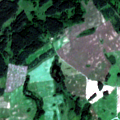


Patch: S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_03_79
Question: Answer the following multiple-choice satellite image question with the correct option letter.

Which pair of classes are touching in the image? a) Land principally occupied by agriculture, with significant areas of natural vegetation and Pastures, b) Arable land and Mixed forest, c) Natural grassland and sparsely vegetated areas and Pastures, d) Industrial or commercial units and Inland wetlands
Ground truth: b


In [55]:
import matplotlib.pyplot as plt
from PIL import Image

sample = random.choice(
    qwen_train_records
)

image_path = os.path.join(
    DATASET_DIR,
    sample["messages"][0]["content"][0]["image"]
)

image = Image.open(
    image_path
)

display(image)

print("\nPatch:", sample["patch_id"])
print(
    "Question:",
    sample["messages"][0]["content"][1]["text"]
)
print(
    "Ground truth:",
    sample["messages"][1]["content"][0]["text"]
)

In [56]:
!pip -q install -U \
    transformers \
    accelerate \
    qwen-vl-utils \
    bitsandbytes \
    peft

In [57]:
import torch
import transformers
import peft
import bitsandbytes

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)
print("bitsandbytes:", bitsandbytes.__version__)
print("CUDA:", torch.cuda.is_available())

PyTorch: 2.11.0+cu128
Transformers: 5.16.1
PEFT: 0.20.0
bitsandbytes: 0.50.2
CUDA: True


In [58]:
from transformers import AutoProcessor

BASE_MODEL = (
    "Qwen/Qwen2.5-VL-3B-Instruct"
)

processor = AutoProcessor.from_pretrained(
    BASE_MODEL,
    min_pixels=256 * 28 * 28,
    max_pixels=768 * 28 * 28
)

print("✅ Processor loaded")

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

✅ Processor loaded


In [59]:
import torch

from transformers import (
    BitsAndBytesConfig,
    Qwen2_5_VLForConditionalGeneration
)

bnb_config = BitsAndBytesConfig(

    load_in_4bit=True,

    bnb_4bit_quant_type="nf4",

    bnb_4bit_compute_dtype=torch.float16,

    bnb_4bit_use_double_quant=True
)

print(
    "Loading Qwen 2.5 VL 3B in 4-bit..."
)

model = (
    Qwen2_5_VLForConditionalGeneration
    .from_pretrained(

        BASE_MODEL,

        quantization_config=bnb_config,

        device_map="auto",

        torch_dtype=torch.float16
    )
)

print("✅ 4-bit model loaded")
print("Device:", model.device)

Loading Qwen 2.5 VL 3B in 4-bit...


model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

✅ 4-bit model loaded
Device: cuda:0


In [60]:
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training
)

model = prepare_model_for_kbit_training(
    model
)

lora_config = LoraConfig(

    r=16,

    lora_alpha=32,

    lora_dropout=0.05,

    bias="none",

    task_type="CAUSAL_LM",

    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj"
    ]
)

model = get_peft_model(
    model,
    lora_config
)

model.print_trainable_parameters()

trainable params: 37,152,768 || all params: 3,791,775,744 || trainable%: 0.9798


In [61]:
model.config.use_cache = False

print(
    "use_cache:",
    model.config.use_cache
)

print(
    "Gradient checkpointing:",
    model.is_gradient_checkpointing
)

use_cache: False
Gradient checkpointing: True


In [62]:
import json
import random

def load_jsonl(path):

    records = []

    with open(
        path,
        "r",
        encoding="utf-8"
    ) as f:

        for line in f:

            records.append(
                json.loads(line)
            )

    return records


train_records = load_jsonl(
    QWEN_TRAIN_JSONL
)

val_records = load_jsonl(
    QWEN_VAL_JSONL
)

print(
    "Training:",
    len(train_records)
)

print(
    "Validation:",
    len(val_records)
)

random.seed(42)

random.shuffle(
    train_records
)

Training: 20000
Validation: 7960


In [87]:
# ============================================================
# STEP 48C — CORRECT DATASET PREPARATION
# ============================================================

import os
import numpy as np
import torch
from PIL import Image


def prepare_training_example(record):

    # --------------------------------------------------------
    # 1. Read fields from YOUR actual JSONL format
    # --------------------------------------------------------

    patch_id = record["patch_id"]

    question = record["question"]

    answer = record["answer"]

    rgb_relative = record["image"]

    multispectral_relative = record["multispectral"]


    # --------------------------------------------------------
    # 2. Resolve RGB path
    # --------------------------------------------------------

    # Your JSON says:
    # images/rgb/filename.png
    #
    # BigEarthNet_4508 is the root containing images/

    rgb_path = os.path.join(
        DATASET_DIR,
        rgb_relative
    )


    # --------------------------------------------------------
    # 3. Resolve multispectral path
    # --------------------------------------------------------

    multispectral_path = os.path.join(
        DATASET_DIR,
        multispectral_relative
    )


    # --------------------------------------------------------
    # 4. Safety checks
    # --------------------------------------------------------

    if not os.path.isfile(rgb_path):

        raise FileNotFoundError(
            f"RGB image not found:\n{rgb_path}"
        )

    if not os.path.isfile(multispectral_path):

        raise FileNotFoundError(
            f"Multispectral file not found:\n"
            f"{multispectral_path}"
        )


    # --------------------------------------------------------
    # 5. Load RGB image
    # --------------------------------------------------------

    image = Image.open(rgb_path).convert("RGB")


    # --------------------------------------------------------
    # 6. Load multispectral data
    # --------------------------------------------------------

    multispectral = np.load(
        multispectral_path
    )


    # --------------------------------------------------------
    # 7. Get actual array from NPZ
    # --------------------------------------------------------

    if isinstance(multispectral, np.lib.npyio.NpzFile):

        keys = list(multispectral.keys())

        if len(keys) == 0:

            multispectral.close()

            raise ValueError(
                f"Empty NPZ file:\n{multispectral_path}"
            )

        ms_array = multispectral[keys[0]]

        multispectral.close()

    else:

        ms_array = multispectral


    # --------------------------------------------------------
    # 8. Convert to numpy
    # --------------------------------------------------------

    ms_array = np.asarray(
        ms_array,
        dtype=np.float32
    )


    # --------------------------------------------------------
    # 9. Basic validation
    # --------------------------------------------------------

    if ms_array.size == 0:

        raise ValueError(
            f"Empty multispectral array:\n"
            f"{multispectral_path}"
        )


    # --------------------------------------------------------
    # 10. Build the question-answer prompt
    # --------------------------------------------------------

    prompt = (
        "Answer the following question about the satellite "
        "image concisely.\n\n"
        f"Question: {question}\n\n"
        "Answer:"
    )


    # --------------------------------------------------------
    # 11. Return everything required by training
    # --------------------------------------------------------

    return {
        "patch_id": patch_id,

        "image": image,

        "multispectral": ms_array,

        "question": question,

        "answer": answer,

        "prompt": prompt,

        "rgb_path": rgb_path,

        "multispectral_path": multispectral_path,

        "type": record.get("type", ""),

        "category": record.get("category", "")
    }


print("=" * 70)
print("✅ CORRECT DATA PREPARATION FUNCTION LOADED")
print("=" * 70)

✅ CORRECT DATA PREPARATION FUNCTION LOADED


In [88]:
# ============================================================
# STEP 48D — TEST ONE REAL DATASET RECORD
# ============================================================

print("=" * 70)
print("TESTING ONE REAL TRAINING RECORD")
print("=" * 70)


with open(TRAIN_FILE, "r", encoding="utf-8") as f:

    record = json.loads(f.readline())


print("\nPatch ID:")
print(record["patch_id"])

print("\nQuestion:")
print(record["question"])

print("\nAnswer:")
print(record["answer"])

print("\nRGB relative path:")
print(record["image"])

print("\nMultispectral relative path:")
print(record["multispectral"])


example = prepare_training_example(record)


print("\n" + "=" * 70)
print("RESULT")
print("=" * 70)

print("Patch ID:", example["patch_id"])

print("RGB path:")
print(example["rgb_path"])

print("RGB exists:", os.path.isfile(example["rgb_path"]))

print("\nMultispectral path:")
print(example["multispectral_path"])

print(
    "Multispectral exists:",
    os.path.isfile(example["multispectral_path"])
)

print("\nRGB size:")
print(example["image"].size)

print("\nMultispectral shape:")
print(example["multispectral"].shape)

print("\nMultispectral dtype:")
print(example["multispectral"].dtype)

print("\nQuestion:")
print(example["question"])

print("\nAnswer:")
print(example["answer"])

print("\nPrompt:")
print(example["prompt"])

print("\n" + "=" * 70)
print("✅ REAL DATASET RECORD PASSED")
print("=" * 70)

TESTING ONE REAL TRAINING RECORD

Patch ID:
S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_65_03

Question:
Is any inland water and marine waters adjoining regions in this scene?

Answer:
no

RGB relative path:
images/rgb/S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_65_03.png

Multispectral relative path:
images/multispectral/S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_65_03.npz

RESULT
Patch ID: S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_65_03
RGB path:
/content/drive/MyDrive/finalProject/BigEarthNet_4508/images/rgb/S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_65_03.png
RGB exists: True

Multispectral path:
/content/drive/MyDrive/finalProject/BigEarthNet_4508/images/multispectral/S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_65_03.npz
Multispectral exists: True

RGB size:
(120, 120)

Multispectral shape:
(12, 120, 120)

Multispectral dtype:
float32

Question:
Is any inland water and marine waters adjoining regions in this scene?

Answer:
no

Prompt:
Answer the following question about

In [89]:
# ============================================================
# STEP 48E — TEST PROCESSOR WITH REAL RGB IMAGE
# ============================================================

print("=" * 70)
print("TESTING PROCESSOR")
print("=" * 70)


messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": example["image"]
            },
            {
                "type": "text",
                "text": example["prompt"]
            }
        ]
    }
]


text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)


inputs = processor(
    text=[text],
    images=[example["image"]],
    return_tensors="pt"
)


print("Processor output keys:")

for key, value in inputs.items():

    if hasattr(value, "shape"):

        print(
            f"  {key:<20}: {tuple(value.shape)}"
        )

    else:

        print(
            f"  {key:<20}: {type(value)}"
        )


print("\nMoving tensors to GPU...")

for key in inputs:

    if torch.is_tensor(inputs[key]):

        inputs[key] = inputs[key].to(
            model.device
        )


print("✅ Processor test passed")

print("=" * 70)

TESTING PROCESSOR
Processor output keys:
  input_ids           : (1, 306)
  attention_mask      : (1, 306)
  mm_token_type_ids   : (1, 306)
  pixel_values        : (1024, 1176)
  image_grid_thw      : (1, 3)

Moving tensors to GPU...
✅ Processor test passed


In [64]:
test_inputs = (
    prepare_training_example(
        train_records[0]
    )
)

test_inputs = {
    k: v.to(model.device)
    if torch.is_tensor(v)
    else v

    for k, v in test_inputs.items()
}

print(
    "Input shape:",
    test_inputs["input_ids"].shape
)

print(
    "Training tokens:",
    (
        test_inputs["labels"] != -100
    ).sum().item()
)

model.train()

outputs = model(
    **test_inputs
)

print(
    "✅ Forward pass successful"
)

print(
    "Loss:",
    outputs.loss.item()
)

Input shape: torch.Size([1, 353])
Training tokens: 3


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:957: UserWarning: inner dimension (3420) is not aligned for fast kernel with blocksize=64, falling back to slower implementation.
  warn(
[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


✅ Forward pass successful
Loss: 0.9724245667457581


In [65]:
# ============================================================
# STEP 31 — TRAINING CONFIGURATION
# ============================================================

BATCH_SIZE = 1

GRAD_ACCUM_STEPS = 8

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 0.01

MAX_STEPS = 500

# Save every 50 optimizer steps
SAVE_EVERY = 50

# Keep multiple checkpoints for recovery
MAX_CHECKPOINTS = 10

SEED = 42

print("=" * 60)
print("TRAINING CONFIGURATION")
print("=" * 60)

print(f"BATCH_SIZE              : {BATCH_SIZE}")
print(f"GRAD_ACCUM_STEPS        : {GRAD_ACCUM_STEPS}")
print(f"EFFECTIVE BATCH SIZE    : {BATCH_SIZE * GRAD_ACCUM_STEPS}")
print(f"LEARNING_RATE            : {LEARNING_RATE}")
print(f"WEIGHT_DECAY             : {WEIGHT_DECAY}")
print(f"MAX_STEPS                : {MAX_STEPS}")
print(f"SAVE_EVERY               : {SAVE_EVERY}")
print(f"MAX_CHECKPOINTS          : {MAX_CHECKPOINTS}")
print(f"SEED                     : {SEED}")

print("=" * 60)

TRAINING CONFIGURATION
BATCH_SIZE              : 1
GRAD_ACCUM_STEPS        : 8
EFFECTIVE BATCH SIZE    : 8
LEARNING_RATE            : 0.0001
WEIGHT_DECAY             : 0.01
MAX_STEPS                : 500
SAVE_EVERY               : 50
MAX_CHECKPOINTS          : 10
SEED                     : 42


In [67]:
# ============================================================
# STEP 34 — VERIFY DRIVE STRUCTURE
# ============================================================

print("=" * 60)
print("VERIFYING GOOGLE DRIVE")
print("=" * 60)

for directory in [
    PROJECT_DIR,
    DATASET_DIR,
    CHECKPOINT_DIR,
    LOG_DIR,
    FINAL_MODEL_DIR
]:

    if os.path.isdir(directory):
        print("✅", directory)

    else:
        print("❌", directory)

print("\nGoogle Drive structure is ready.")

VERIFYING GOOGLE DRIVE
✅ /content/drive/MyDrive/finalProject
❌ /content/drive/MyDrive/finalProject/dataset
❌ /content/drive/MyDrive/finalProject/checkpoints
❌ /content/drive/MyDrive/finalProject/logs
❌ /content/drive/MyDrive/finalProject/final_model

Google Drive structure is ready.


In [68]:
# ============================================================
# STEP 34 — CREATE + VERIFY GOOGLE DRIVE DIRECTORIES
# ============================================================

import os

PROJECT_DIR = "/content/drive/MyDrive/finalProject"

DATASET_DIR = os.path.join(PROJECT_DIR, "dataset")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
LOG_DIR = os.path.join(PROJECT_DIR, "logs")
FINAL_MODEL_DIR = os.path.join(PROJECT_DIR, "final_model")

directories = {
    "Project": PROJECT_DIR,
    "Dataset": DATASET_DIR,
    "Checkpoints": CHECKPOINT_DIR,
    "Logs": LOG_DIR,
    "Final Model": FINAL_MODEL_DIR
}

print("=" * 70)
print("CREATING FINALPROJECT DIRECTORIES")
print("=" * 70)

# ------------------------------------------------------------
# CREATE DIRECTORIES
# ------------------------------------------------------------

for name, path in directories.items():

    try:
        os.makedirs(path, exist_ok=True)

        # Immediately verify
        if os.path.isdir(path):
            print(f"✅ {name:<15}: {path}")
        else:
            print(f"❌ {name:<15}: FAILED")

    except Exception as e:
        print(f"❌ {name:<15}: {e}")


# ------------------------------------------------------------
# FINAL VERIFICATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL DIRECTORY VERIFICATION")
print("=" * 70)

all_ok = True

for name, path in directories.items():

    exists = os.path.isdir(path)

    if exists:
        print(f"✅ {name:<15}: EXISTS")
    else:
        print(f"❌ {name:<15}: MISSING")
        all_ok = False


# ------------------------------------------------------------
# RESULT
# ------------------------------------------------------------

print("\n" + "=" * 70)

if all_ok:
    print("✅ ALL GOOGLE DRIVE DIRECTORIES ARE READY")
else:
    print("❌ DIRECTORY CREATION FAILED")
    print("DO NOT CONTINUE YET.")

print("=" * 70)

CREATING FINALPROJECT DIRECTORIES
✅ Project        : /content/drive/MyDrive/finalProject
✅ Dataset        : /content/drive/MyDrive/finalProject/dataset
✅ Checkpoints    : /content/drive/MyDrive/finalProject/checkpoints
✅ Logs           : /content/drive/MyDrive/finalProject/logs
✅ Final Model    : /content/drive/MyDrive/finalProject/final_model

FINAL DIRECTORY VERIFICATION
✅ Project        : EXISTS
✅ Dataset        : EXISTS
✅ Checkpoints    : EXISTS
✅ Logs           : EXISTS
✅ Final Model    : EXISTS

✅ ALL GOOGLE DRIVE DIRECTORIES ARE READY


In [69]:
# ============================================================
# STEP 35 — CREATE DATASET STORAGE STRUCTURE
# ============================================================

import os

# Dataset subdirectories
RGB_DIR = os.path.join(DATASET_DIR, "rgb")
MULTISPECTRAL_DIR = os.path.join(DATASET_DIR, "multispectral")
METADATA_DIR = os.path.join(DATASET_DIR, "metadata")

# Create them
for directory in [
    RGB_DIR,
    MULTISPECTRAL_DIR,
    METADATA_DIR
]:
    os.makedirs(directory, exist_ok=True)

print("=" * 70)
print("DATASET STORAGE STRUCTURE")
print("=" * 70)

for name, directory in {
    "RGB images": RGB_DIR,
    "Multispectral images": MULTISPECTRAL_DIR,
    "Metadata": METADATA_DIR
}.items():

    if os.path.isdir(directory):
        print(f"✅ {name:<22}: {directory}")
    else:
        print(f"❌ {name:<22}: {directory}")

print("\nDataset structure ready.")

DATASET STORAGE STRUCTURE
✅ RGB images            : /content/drive/MyDrive/finalProject/dataset/rgb
✅ Multispectral images  : /content/drive/MyDrive/finalProject/dataset/multispectral
✅ Metadata              : /content/drive/MyDrive/finalProject/dataset/metadata

Dataset structure ready.


In [70]:
# ============================================================
# STEP 36 — VERIFY DATASET SOURCE
# ============================================================

import os
import sys
import subprocess

print("=" * 70)
print("STEP 36 — DATASET SOURCE VERIFICATION")
print("=" * 70)

print("\nPython version:")
print(sys.version)

print("\nInstalling/checking required packages...")

packages = [
    "numpy",
    "pillow",
    "requests",
    "tqdm",
    "pandas",
    "rasterio"
]

for package in packages:
    try:
        __import__(package)
        print(f"✅ {package}")
    except ImportError:
        print(f"⚠️ {package} not installed")

print("\nGoogle Drive paths:")
print("PROJECT_DIR       :", PROJECT_DIR)
print("DATASET_DIR       :", DATASET_DIR)
print("RGB_DIR           :", RGB_DIR)
print("MULTISPECTRAL_DIR :", MULTISPECTRAL_DIR)
print("METADATA_DIR      :", METADATA_DIR)

print("\nChecking directories...")

for path in [
    PROJECT_DIR,
    DATASET_DIR,
    RGB_DIR,
    MULTISPECTRAL_DIR,
    METADATA_DIR
]:
    print(
        "✅" if os.path.isdir(path) else "❌",
        path
    )

print("\n" + "=" * 70)
print("READY FOR DATASET CREATION")
print("=" * 70)

STEP 36 — DATASET SOURCE VERIFICATION

Python version:
3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]

Installing/checking required packages...
✅ numpy
⚠️ pillow not installed
✅ requests
✅ tqdm
✅ pandas
✅ rasterio

Google Drive paths:
PROJECT_DIR       : /content/drive/MyDrive/finalProject
DATASET_DIR       : /content/drive/MyDrive/finalProject/dataset
RGB_DIR           : /content/drive/MyDrive/finalProject/dataset/rgb
MULTISPECTRAL_DIR : /content/drive/MyDrive/finalProject/dataset/multispectral
METADATA_DIR      : /content/drive/MyDrive/finalProject/dataset/metadata

Checking directories...
✅ /content/drive/MyDrive/finalProject
✅ /content/drive/MyDrive/finalProject/dataset
✅ /content/drive/MyDrive/finalProject/dataset/rgb
✅ /content/drive/MyDrive/finalProject/dataset/multispectral
✅ /content/drive/MyDrive/finalProject/dataset/metadata

READY FOR DATASET CREATION


In [71]:
# ============================================================
# STEP 37 — INSTALL DATASET PROCESSING DEPENDENCIES
# ============================================================

import sys
import subprocess

print("=" * 70)
print("STEP 37 — INSTALLING DATASET DEPENDENCIES")
print("=" * 70)

packages = [
    "pillow",
    "numpy",
    "pandas",
    "requests",
    "tqdm",
    "rasterio",
    "huggingface_hub",
    "datasets"
]

for package in packages:

    print(f"\nInstalling/checking: {package}")

    result = subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package
        ],
        capture_output=True,
        text=True
    )

    if result.returncode == 0:
        print(f"✅ {package}")
    else:
        print(f"❌ Failed: {package}")
        print(result.stderr[-1000:])

print("\n" + "=" * 70)
print("VERIFYING IMPORTS")
print("=" * 70)

# Important imports
import numpy as np
import pandas as pd
import requests
import rasterio

from PIL import Image
from tqdm.auto import tqdm

print("✅ numpy")
print("✅ pandas")
print("✅ requests")
print("✅ rasterio")
print("✅ PIL / Pillow")
print("✅ tqdm")

print("\n" + "=" * 70)
print("✅ DATASET ENVIRONMENT READY")
print("=" * 70)

STEP 37 — INSTALLING DATASET DEPENDENCIES

Installing/checking: pillow
✅ pillow

Installing/checking: numpy
✅ numpy

Installing/checking: pandas
✅ pandas

Installing/checking: requests
✅ requests

Installing/checking: tqdm
✅ tqdm

Installing/checking: rasterio
✅ rasterio

Installing/checking: huggingface_hub
✅ huggingface_hub

Installing/checking: datasets
✅ datasets

VERIFYING IMPORTS
✅ numpy
✅ pandas
✅ requests
✅ rasterio
✅ PIL / Pillow
✅ tqdm

✅ DATASET ENVIRONMENT READY


In [72]:
# ============================================================
# STEP 38 — FINAL PROJECT CONFIGURATION
# ============================================================

import os
import json
import random
import numpy as np
import torch

# ------------------------------------------------------------
# PROJECT PATHS
# ------------------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/finalProject"

DATASET_DIR = os.path.join(
    PROJECT_DIR,
    "dataset"
)

RGB_DIR = os.path.join(
    DATASET_DIR,
    "rgb"
)

MULTISPECTRAL_DIR = os.path.join(
    DATASET_DIR,
    "multispectral"
)

METADATA_DIR = os.path.join(
    DATASET_DIR,
    "metadata"
)

CHECKPOINT_DIR = os.path.join(
    PROJECT_DIR,
    "checkpoints"
)

LOG_DIR = os.path.join(
    PROJECT_DIR,
    "logs"
)

FINAL_MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "final_model"
)

# ------------------------------------------------------------
# DATASET FILES
# ------------------------------------------------------------

TRAIN_FILE = os.path.join(
    DATASET_DIR,
    "qwen_train.jsonl"
)

VAL_FILE = os.path.join(
    DATASET_DIR,
    "qwen_val.jsonl"
)

# ------------------------------------------------------------
# CREATE EVERYTHING
# ------------------------------------------------------------

directories = [
    PROJECT_DIR,
    DATASET_DIR,
    RGB_DIR,
    MULTISPECTRAL_DIR,
    METADATA_DIR,
    CHECKPOINT_DIR,
    LOG_DIR,
    FINAL_MODEL_DIR
]

for directory in directories:
    os.makedirs(directory, exist_ok=True)

# ------------------------------------------------------------
# TRAINING CONFIG
# ------------------------------------------------------------

SEED = 42

BATCH_SIZE = 1

GRAD_ACCUM_STEPS = 8

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 0.01

MAX_STEPS = 500

SAVE_EVERY = 50

MAX_CHECKPOINTS = 5

BASE_MODEL = "Qwen/Qwen2.5-VL-3B-Instruct"

# ------------------------------------------------------------
# REPRODUCIBILITY
# ------------------------------------------------------------

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# SAVE CONFIGURATION TO DRIVE
# ------------------------------------------------------------

CONFIG_FILE = os.path.join(
    PROJECT_DIR,
    "project_config.json"
)

config = {
    "project_dir": PROJECT_DIR,
    "dataset_dir": DATASET_DIR,
    "rgb_dir": RGB_DIR,
    "multispectral_dir": MULTISPECTRAL_DIR,
    "metadata_dir": METADATA_DIR,
    "checkpoint_dir": CHECKPOINT_DIR,
    "log_dir": LOG_DIR,
    "final_model_dir": FINAL_MODEL_DIR,
    "train_file": TRAIN_FILE,
    "val_file": VAL_FILE,
    "base_model": BASE_MODEL,
    "seed": SEED,
    "batch_size": BATCH_SIZE,
    "gradient_accumulation_steps": GRAD_ACCUM_STEPS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "max_steps": MAX_STEPS,
    "save_every": SAVE_EVERY,
    "max_checkpoints": MAX_CHECKPOINTS
}

with open(CONFIG_FILE, "w") as f:
    json.dump(config, f, indent=2)

print("=" * 70)
print("STEP 38 — PROJECT CONFIGURATION")
print("=" * 70)

for key, value in config.items():
    print(f"{key:<32}: {value}")

print("\n✅ Configuration permanently saved:")
print(CONFIG_FILE)

STEP 38 — PROJECT CONFIGURATION
project_dir                     : /content/drive/MyDrive/finalProject
dataset_dir                     : /content/drive/MyDrive/finalProject/dataset
rgb_dir                         : /content/drive/MyDrive/finalProject/dataset/rgb
multispectral_dir               : /content/drive/MyDrive/finalProject/dataset/multispectral
metadata_dir                    : /content/drive/MyDrive/finalProject/dataset/metadata
checkpoint_dir                  : /content/drive/MyDrive/finalProject/checkpoints
log_dir                         : /content/drive/MyDrive/finalProject/logs
final_model_dir                 : /content/drive/MyDrive/finalProject/final_model
train_file                      : /content/drive/MyDrive/finalProject/dataset/qwen_train.jsonl
val_file                        : /content/drive/MyDrive/finalProject/dataset/qwen_val.jsonl
base_model                      : Qwen/Qwen2.5-VL-3B-Instruct
seed                            : 42
batch_size                      :

In [73]:
# ============================================================
# CURRENT STATE CHECK
# ============================================================

print("=" * 70)
print("CURRENT TRAINING ENVIRONMENT")
print("=" * 70)

# Model
if "model" in globals():
    print("✅ model loaded")
    print("   Type:", type(model))
else:
    print("❌ model NOT loaded")

# Processor
if "processor" in globals():
    print("✅ processor loaded")
else:
    print("❌ processor NOT loaded")

# Dataset paths
print("\nDataset:")
print("TRAIN_FILE:", TRAIN_FILE)
print("VAL_FILE  :", VAL_FILE)

print("\nTraining JSONL:")
print("✅ EXISTS" if os.path.isfile(TRAIN_FILE) else "❌ MISSING")

print("\nValidation JSONL:")
print("✅ EXISTS" if os.path.isfile(VAL_FILE) else "❌ MISSING")

# GPU
print("\nGPU:")
if torch.cuda.is_available():
    print("✅ CUDA:", torch.cuda.get_device_name(0))
else:
    print("❌ CUDA unavailable")

# LoRA
print("\nLoRA:")
try:
    model.print_trainable_parameters()
except Exception as e:
    print("Could not inspect LoRA:", e)

print("=" * 70)

CURRENT TRAINING ENVIRONMENT
✅ model loaded
   Type: <class 'peft.peft_model.PeftModelForCausalLM'>
✅ processor loaded

Dataset:
TRAIN_FILE: /content/drive/MyDrive/finalProject/dataset/qwen_train.jsonl
VAL_FILE  : /content/drive/MyDrive/finalProject/dataset/qwen_val.jsonl

Training JSONL:
❌ MISSING

Validation JSONL:
❌ MISSING

GPU:
✅ CUDA: Tesla T4

LoRA:
trainable params: 37,152,768 || all params: 3,791,775,744 || trainable%: 0.9798


In [74]:
# ============================================================
# STEP 61 — RESTORE ACTUAL DATASET PATHS
# ============================================================

import os

PROJECT_DIR = "/content/drive/MyDrive/finalProject"

# ------------------------------------------------------------
# ACTUAL DATASET
# ------------------------------------------------------------

DATASET_DIR = os.path.join(
    PROJECT_DIR,
    "BigEarthNet_4508"
)

# Images created by the extraction process
RGB_DIR = os.path.join(
    DATASET_DIR,
    "images",
    "rgb"
)

MULTISPECTRAL_DIR = os.path.join(
    DATASET_DIR,
    "images",
    "multispectral"
)

# Dataset files
TRAIN_FILE = os.path.join(
    DATASET_DIR,
    "train.jsonl"
)

VAL_FILE = os.path.join(
    DATASET_DIR,
    "val.jsonl"
)

VQA_TRAIN_JSONL = os.path.join(
    DATASET_DIR,
    "vqa_train.jsonl"
)

VQA_VAL_JSONL = os.path.join(
    DATASET_DIR,
    "vqa_val.jsonl"
)

QWEN_TRAIN_JSONL = os.path.join(
    DATASET_DIR,
    "qwen_train.jsonl"
)

QWEN_VAL_JSONL = os.path.join(
    DATASET_DIR,
    "qwen_val.jsonl"
)

REVIEW_DIR = os.path.join(
    DATASET_DIR,
    "dataset_review"
)

# ------------------------------------------------------------
# TRAINING OUTPUT
# ------------------------------------------------------------

CHECKPOINT_DIR = os.path.join(
    PROJECT_DIR,
    "qwen_lora_checkpoints"
)

FINAL_MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "final_qwen_lora"
)

LOG_DIR = os.path.join(
    PROJECT_DIR,
    "training_logs"
)

# ------------------------------------------------------------
# CREATE TRAINING OUTPUT DIRECTORIES
# ------------------------------------------------------------

for directory in [
    CHECKPOINT_DIR,
    FINAL_MODEL_DIR,
    LOG_DIR
]:
    os.makedirs(
        directory,
        exist_ok=True
    )

print("=" * 70)
print("CORRECT DATASET PATHS")
print("=" * 70)

print("Dataset:")
print(DATASET_DIR)

print("\nQwen train:")
print(QWEN_TRAIN_JSONL)

print("\nQwen validation:")
print(QWEN_VAL_JSONL)

print("\nCheckpoints:")
print(CHECKPOINT_DIR)

print("\nFinal model:")
print(FINAL_MODEL_DIR)

print("\nLogs:")
print(LOG_DIR)

CORRECT DATASET PATHS
Dataset:
/content/drive/MyDrive/finalProject/BigEarthNet_4508

Qwen train:
/content/drive/MyDrive/finalProject/BigEarthNet_4508/qwen_train.jsonl

Qwen validation:
/content/drive/MyDrive/finalProject/BigEarthNet_4508/qwen_val.jsonl

Checkpoints:
/content/drive/MyDrive/finalProject/qwen_lora_checkpoints

Final model:
/content/drive/MyDrive/finalProject/final_qwen_lora

Logs:
/content/drive/MyDrive/finalProject/training_logs


In [75]:
# ============================================================
# STEP 62 — DATASET + IMAGE VERIFICATION
# ============================================================

import os
import json

print("=" * 70)
print("FINAL DATASET VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. DATASET DIRECTORY
# ------------------------------------------------------------

print("\n[1] DATASET")

if os.path.isdir(DATASET_DIR):
    print("✅ Dataset directory exists")
    print(DATASET_DIR)
else:
    raise RuntimeError(
        f"❌ Dataset directory missing:\n{DATASET_DIR}"
    )


# ------------------------------------------------------------
# 2. REQUIRED JSONL FILES
# ------------------------------------------------------------

required_files = {
    "train.jsonl": TRAIN_FILE,
    "val.jsonl": VAL_FILE,
    "vqa_train.jsonl": VQA_TRAIN_JSONL,
    "vqa_val.jsonl": VQA_VAL_JSONL,
    "qwen_train.jsonl": QWEN_TRAIN_JSONL,
    "qwen_val.jsonl": QWEN_VAL_JSONL,
}

print("\n[2] DATASET FILES")

for name, path in required_files.items():

    if os.path.isfile(path):

        size_mb = (
            os.path.getsize(path)
            / (1024 * 1024)
        )

        print(
            f"✅ {name:<18} "
            f"{size_mb:.2f} MB"
        )

    else:

        print(
            f"❌ {name:<18} MISSING"
        )


# ------------------------------------------------------------
# 3. QWEN TRAIN JSONL
# ------------------------------------------------------------

print("\n[3] QWEN TRAINING DATA")

if not os.path.isfile(QWEN_TRAIN_JSONL):

    raise RuntimeError(
        "❌ qwen_train.jsonl not found"
    )

with open(
    QWEN_TRAIN_JSONL,
    "r",
    encoding="utf-8"
) as f:

    train_records_check = [
        json.loads(line)
        for line in f
        if line.strip()
    ]

print(
    "Training records:",
    len(train_records_check)
)


# ------------------------------------------------------------
# 4. QWEN VALIDATION JSONL
# ------------------------------------------------------------

print("\n[4] QWEN VALIDATION DATA")

if not os.path.isfile(QWEN_VAL_JSONL):

    raise RuntimeError(
        "❌ qwen_val.jsonl not found"
    )

with open(
    QWEN_VAL_JSONL,
    "r",
    encoding="utf-8"
) as f:

    val_records_check = [
        json.loads(line)
        for line in f
        if line.strip()
    ]

print(
    "Validation records:",
    len(val_records_check)
)


# ------------------------------------------------------------
# 5. IMAGE PATH CHECK
# ------------------------------------------------------------

print("\n[5] IMAGE REFERENCES")

missing_images = []

for record in train_records_check[:100]:

    relative_image = (
        record["messages"]
        [0]["content"]
        [0]["image"]
    )

    image_path = os.path.join(
        DATASET_DIR,
        relative_image
    )

    if not os.path.isfile(image_path):

        missing_images.append(
            image_path
        )

print(
    "Checked:",
    min(100, len(train_records_check)),
    "training records"
)

print(
    "Missing images:",
    len(missing_images)
)

if missing_images:

    print("\nFirst missing images:")

    for path in missing_images[:5]:
        print(path)

    raise RuntimeError(
        "❌ Some referenced images are missing."
    )

else:

    print("✅ Image references are valid")


# ------------------------------------------------------------
# 6. CHECKPOINT DIRECTORY
# ------------------------------------------------------------

print("\n[6] CHECKPOINT DIRECTORY")

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

print(
    "✅",
    CHECKPOINT_DIR
)


# ------------------------------------------------------------
# 7. FINAL MODEL DIRECTORY
# ------------------------------------------------------------

print("\n[7] FINAL MODEL DIRECTORY")

os.makedirs(
    FINAL_MODEL_DIR,
    exist_ok=True
)

print(
    "✅",
    FINAL_MODEL_DIR
)


print("\n" + "=" * 70)
print("✅ DATASET VERIFICATION PASSED")
print("=" * 70)

FINAL DATASET VERIFICATION

[1] DATASET
✅ Dataset directory exists
/content/drive/MyDrive/finalProject/BigEarthNet_4508

[2] DATASET FILES
✅ train.jsonl        39.63 MB
✅ val.jsonl          5.08 MB
✅ vqa_train.jsonl    11.39 MB
✅ vqa_val.jsonl      3.77 MB
✅ qwen_train.jsonl   15.38 MB
✅ qwen_val.jsonl     5.36 MB

[3] QWEN TRAINING DATA
Training records: 20000

[4] QWEN VALIDATION DATA
Validation records: 7960

[5] IMAGE REFERENCES
Checked: 100 training records
Missing images: 0
✅ Image references are valid

[6] CHECKPOINT DIRECTORY
✅ /content/drive/MyDrive/finalProject/qwen_lora_checkpoints

[7] FINAL MODEL DIRECTORY
✅ /content/drive/MyDrive/finalProject/final_qwen_lora

✅ DATASET VERIFICATION PASSED


In [76]:
# ============================================================
# STEP 63 — LOAD FINAL QWEN DATASET
# ============================================================

import json
import random

def load_jsonl(path):

    records = []

    with open(
        path,
        "r",
        encoding="utf-8"
    ) as f:

        for line in f:

            if line.strip():

                records.append(
                    json.loads(line)
                )

    return records


train_records = load_jsonl(
    QWEN_TRAIN_JSONL
)

val_records = load_jsonl(
    QWEN_VAL_JSONL
)

print("=" * 70)
print("FINAL DATASET")
print("=" * 70)

print(
    "Training records   :",
    len(train_records)
)

print(
    "Validation records :",
    len(val_records)
)

# Distribution
from collections import Counter

print("\nTraining distribution:")

for task, count in Counter(
    r.get("type")
    for r in train_records
).items():

    print(
        f"  {task:<15}: {count}"
    )

print("\nValidation distribution:")

for task, count in Counter(
    r.get("type")
    for r in val_records
).items():

    print(
        f"  {task:<15}: {count}"
    )

# Shuffle training data
random.seed(SEED)

random.shuffle(
    train_records
)

print("\n✅ Final Qwen dataset loaded")

FINAL DATASET
Training records   : 20000
Validation records : 7960

Training distribution:
  binary         : 8000
  captioning     : 4000
  mcq            : 8000

Validation distribution:
  binary         : 3895
  captioning     : 500
  mcq            : 3565

✅ Final Qwen dataset loaded


In [77]:
# ============================================================
# STEP 64 — FINAL FORWARD PASS TEST
# ============================================================

print("=" * 70)
print("FINAL FORWARD PASS TEST")
print("=" * 70)

test_record = train_records[0]

print("\nPatch:")
print(test_record["patch_id"])

print("\nQuestion:")
print(
    test_record["messages"]
    [0]["content"]
    [1]["text"]
)

print("\nAnswer:")
print(
    test_record["messages"]
    [1]["content"]
    [0]["text"]
)

test_inputs = prepare_training_example(
    test_record
)

test_inputs = {
    k: (
        v.to(model.device)
        if torch.is_tensor(v)
        else v
    )
    for k, v in test_inputs.items()
}

print("\nInput shape:")
print(
    test_inputs["input_ids"].shape
)

print("\nTrainable tokens:")
print(
    (
        test_inputs["labels"] != -100
    ).sum().item()
)

model.train()

with torch.no_grad():

    outputs = model(
        **test_inputs
    )

print("\nLoss:")
print(
    outputs.loss.item()
)

if not torch.isfinite(outputs.loss):

    raise RuntimeError(
        "❌ Loss is NaN or infinite."
    )

print("\n" + "=" * 70)
print("✅ FORWARD PASS PASSED")
print("=" * 70)

FINAL FORWARD PASS TEST

Patch:
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_21_87

Question:
Answer the following multiple-choice satellite image question with the correct option letter.

From the options below, choose the climate zone shown in the satellite image: a) Temperate, no dry season, cold summer, b) Cold, no dry season, warm summer, c) Temperate, no dry season, hot summer, d) Arid, steppe, cold

Answer:
b

Input shape:
torch.Size([1, 353])

Trainable tokens:
3


/usr/local/lib/python3.13/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)



Loss:
0.9724245667457581

✅ FORWARD PASS PASSED


In [78]:
# ============================================================
# STEP 65 — GRADIENT FLOW TEST
# ============================================================

print("=" * 70)
print("GRADIENT FLOW TEST")
print("=" * 70)

model.train()

# Prepare one training example
test_record = train_records[0]

test_inputs = prepare_training_example(
    test_record
)

test_inputs = {
    k: (
        v.to(model.device)
        if torch.is_tensor(v)
        else v
    )
    for k, v in test_inputs.items()
}

# IMPORTANT:
# No torch.no_grad() here
outputs = model(
    **test_inputs
)

loss = outputs.loss

print("Loss:", loss.item())
print("Loss requires_grad:", loss.requires_grad)

# Backward
loss.backward()

# Check LoRA gradients
gradient_params = 0
gradient_norm = 0.0

for name, param in model.named_parameters():

    if param.requires_grad:

        if param.grad is not None:

            gradient_params += 1

            gradient_norm += (
                param.grad.detach()
                .float()
                .norm()
                .item() ** 2
            )

gradient_norm = gradient_norm ** 0.5

print("\nTrainable parameters with gradients:")
print(gradient_params)

print("Gradient norm:")
print(gradient_norm)

# Cleanup
model.zero_grad(set_to_none=True)

if not loss.requires_grad:
    raise RuntimeError(
        "❌ Loss does not require gradients."
    )

if gradient_params == 0:
    raise RuntimeError(
        "❌ No trainable parameters received gradients."
    )

if not np.isfinite(gradient_norm):
    raise RuntimeError(
        "❌ Gradient norm is NaN or infinite."
    )

print("\n" + "=" * 70)
print("✅ GRADIENT FLOW PASSED")
print("=" * 70)
print("The model is ready for training.")

GRADIENT FLOW TEST
Loss: 0.9724245667457581
Loss requires_grad: True

Trainable parameters with gradients:
696
Gradient norm:
6.635170916930326

✅ GRADIENT FLOW PASSED
The model is ready for training.


In [79]:
# ============================================================
# STEP 42 — VERIFY TRAINING DATA
# ============================================================

import os
import json

print("=" * 70)
print("STEP 42 — TRAINING DATA VERIFICATION")
print("=" * 70)

print("\nTraining file:")
print(TRAIN_FILE)

print("\nValidation file:")
print(VAL_FILE)

assert os.path.isfile(TRAIN_FILE), f"Training file missing: {TRAIN_FILE}"
assert os.path.isfile(VAL_FILE), f"Validation file missing: {VAL_FILE}"

print("\n✅ Training JSONL exists")
print("✅ Validation JSONL exists")


# ------------------------------------------------------------
# Read first training example
# ------------------------------------------------------------

with open(TRAIN_FILE, "r", encoding="utf-8") as f:
    first_train = json.loads(f.readline())

print("\n" + "=" * 70)
print("FIRST TRAINING SAMPLE")
print("=" * 70)

print(json.dumps(first_train, indent=2, ensure_ascii=False)[:10000])


# ------------------------------------------------------------
# Read first validation example
# ------------------------------------------------------------

with open(VAL_FILE, "r", encoding="utf-8") as f:
    first_val = json.loads(f.readline())

print("\n" + "=" * 70)
print("FIRST VALIDATION SAMPLE")
print("=" * 70)

print(json.dumps(first_val, indent=2, ensure_ascii=False)[:10000])


print("\n" + "=" * 70)
print("✅ JSONL VERIFICATION PASSED")
print("=" * 70)

STEP 42 — TRAINING DATA VERIFICATION

Training file:
/content/drive/MyDrive/finalProject/BigEarthNet_4508/train.jsonl

Validation file:
/content/drive/MyDrive/finalProject/BigEarthNet_4508/val.jsonl

✅ Training JSONL exists
✅ Validation JSONL exists

FIRST TRAINING SAMPLE
{
  "patch_id": "S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_65_03",
  "split": "train",
  "image": "images/rgb/S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_65_03.png",
  "multispectral": "images/multispectral/S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_65_03.npz",
  "question": "Is any inland water and marine waters adjoining regions in this scene?",
  "answer": "no",
  "type": "binary",
  "category": "adjacency"
}

FIRST VALIDATION SAMPLE
{
  "patch_id": "S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_66_14",
  "split": "validation",
  "image": "images/rgb/S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_66_14.png",
  "multispectral": "images/multispectral/S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_66_14.npz",
  "ques

In [80]:
# ============================================================
# STEP 43 — COUNT TRAIN / VALIDATION DATA
# ============================================================

import json

def count_jsonl(path):
    count = 0

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if line:
                count += 1

    return count


train_count = count_jsonl(TRAIN_FILE)
val_count = count_jsonl(VAL_FILE)

print("=" * 70)
print("DATASET COUNTS")
print("=" * 70)

print(f"Training examples   : {train_count}")
print(f"Validation examples : {val_count}")

print("=" * 70)

assert train_count > 0, "Training dataset is empty!"
assert val_count > 0, "Validation dataset is empty!"

print("✅ Training dataset is non-empty")
print("✅ Validation dataset is non-empty")

DATASET COUNTS
Training examples   : 86164
Validation examples : 10928
✅ Training dataset is non-empty
✅ Validation dataset is non-empty


In [81]:
# ============================================================
# STEP 44 — CREATE OPTIMIZER
# ============================================================

import torch

print("=" * 70)
print("STEP 44 — OPTIMIZER SETUP")
print("=" * 70)

# Only LoRA/trainable parameters
trainable_params = [
    p for p in model.parameters()
    if p.requires_grad
]

print("Trainable parameter tensors:", len(trainable_params))

optimizer = torch.optim.AdamW(
    trainable_params,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Optimizer:", type(optimizer).__name__)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)

print("\n✅ Optimizer created")

STEP 44 — OPTIMIZER SETUP
Trainable parameter tensors: 696
Optimizer: AdamW
Learning rate: 0.0001
Weight decay: 0.01

✅ Optimizer created


In [82]:
# ============================================================
# STEP 45 — LEARNING RATE SCHEDULER
# ============================================================

from transformers import get_linear_schedule_with_warmup

WARMUP_STEPS = 25

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=MAX_STEPS
)

print("=" * 70)
print("STEP 45 — SCHEDULER")
print("=" * 70)

print("Warmup steps :", WARMUP_STEPS)
print("Total steps  :", MAX_STEPS)

print("Initial LR   :", optimizer.param_groups[0]["lr"])

print("\n✅ Scheduler created")

STEP 45 — SCHEDULER
Warmup steps : 25
Total steps  : 500
Initial LR   : 0.0

✅ Scheduler created


In [83]:
# ============================================================
# STEP 46 — SAVE TRAINING CONFIGURATION
# ============================================================

import json
import os

training_config = {
    "base_model": BASE_MODEL,
    "train_file": TRAIN_FILE,
    "val_file": VAL_FILE,

    "batch_size": BATCH_SIZE,
    "gradient_accumulation_steps": GRAD_ACCUM_STEPS,

    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,

    "max_steps": MAX_STEPS,
    "save_every": SAVE_EVERY,

    "warmup_steps": WARMUP_STEPS,

    "max_checkpoints": MAX_CHECKPOINTS,

    "seed": SEED
}

TRAINING_CONFIG_FILE = os.path.join(
    PROJECT_DIR,
    "training_config.json"
)

with open(TRAINING_CONFIG_FILE, "w", encoding="utf-8") as f:
    json.dump(
        training_config,
        f,
        indent=4
    )

print("=" * 70)
print("TRAINING CONFIG SAVED")
print("=" * 70)

print(TRAINING_CONFIG_FILE)

print("\n✅ Configuration saved to Google Drive")

TRAINING CONFIG SAVED
/content/drive/MyDrive/finalProject/training_config.json

✅ Configuration saved to Google Drive


In [90]:
# ============================================================
# STEP 48C — FINAL DATASET PREPARATION
# ============================================================

import os
import json
import numpy as np
from PIL import Image


def prepare_training_example(record):

    # --------------------------------------------------------
    # Actual SatQuery JSONL format
    # --------------------------------------------------------
    #
    # {
    #   "patch_id": "...",
    #   "split": "train",
    #   "image": "images/rgb/....png",
    #   "multispectral": "images/multispectral/....npz",
    #   "question": "...",
    #   "answer": "...",
    #   "type": "...",
    #   "category": "..."
    # }
    #
    # --------------------------------------------------------

    patch_id = record["patch_id"]

    question = record["question"]

    answer = record["answer"]

    rgb_relative = record["image"]

    multispectral_relative = record["multispectral"]


    # --------------------------------------------------------
    # Absolute paths
    # --------------------------------------------------------

    rgb_path = os.path.join(
        DATASET_DIR,
        rgb_relative
    )

    multispectral_path = os.path.join(
        DATASET_DIR,
        multispectral_relative
    )


    # --------------------------------------------------------
    # Safety checks
    # --------------------------------------------------------

    if not os.path.isfile(rgb_path):

        raise FileNotFoundError(
            f"RGB image missing:\n{rgb_path}"
        )


    if not os.path.isfile(multispectral_path):

        raise FileNotFoundError(
            f"Multispectral image missing:\n"
            f"{multispectral_path}"
        )


    # --------------------------------------------------------
    # Load RGB
    # --------------------------------------------------------

    rgb_image = Image.open(
        rgb_path
    ).convert("RGB")


    # --------------------------------------------------------
    # Load multispectral
    # --------------------------------------------------------

    data = np.load(
        multispectral_path
    )


    # NPZ file
    if isinstance(
        data,
        np.lib.npyio.NpzFile
    ):

        keys = list(
            data.keys()
        )

        if len(keys) == 0:

            data.close()

            raise ValueError(
                f"Empty NPZ file:\n"
                f"{multispectral_path}"
            )

        multispectral = np.asarray(
            data[keys[0]],
            dtype=np.float32
        )

        data.close()

    else:

        multispectral = np.asarray(
            data,
            dtype=np.float32
        )


    # --------------------------------------------------------
    # Verify multispectral data
    # --------------------------------------------------------

    if multispectral.ndim != 3:

        raise ValueError(
            f"Expected 3D multispectral data, "
            f"got {multispectral.shape}"
        )


    if multispectral.shape[0] != 12:

        raise ValueError(
            f"Expected 12 spectral bands, "
            f"got {multispectral.shape}"
        )


    if multispectral.shape[1:] != (120, 120):

        raise ValueError(
            f"Expected spatial size (120,120), "
            f"got {multispectral.shape[1:]}"
        )


    # --------------------------------------------------------
    # Prompt
    # --------------------------------------------------------

    prompt = (
        "Answer the following question about the "
        "satellite image concisely.\n\n"
        f"Question: {question}\n\n"
        "Answer:"
    )


    # --------------------------------------------------------
    # Qwen VLM messages
    # --------------------------------------------------------

    messages = [

        {
            "role": "user",

            "content": [

                {
                    "type": "image",
                    "image": rgb_image
                },

                {
                    "type": "text",
                    "text": prompt
                }

            ]
        }

    ]


    # --------------------------------------------------------
    # Return raw + structured information
    # --------------------------------------------------------

    return {

        "patch_id": patch_id,

        "question": question,

        "answer": answer,

        "rgb_image": rgb_image,

        "multispectral": multispectral,

        "rgb_path": rgb_path,

        "multispectral_path":
            multispectral_path,

        "messages": messages,

        "prompt": prompt

    }


print("=" * 70)
print("✅ FINAL DATASET PREPARATION FUNCTION READY")
print("=" * 70)

✅ FINAL DATASET PREPARATION FUNCTION READY


In [91]:
# ============================================================
# STEP 48C-TEST — TEST DATASET PREPARATION
# ============================================================

print("=" * 70)
print("TESTING DATASET PREPARATION")
print("=" * 70)


test_record = train_records[0]


print("\nOriginal record keys:")
print(
    list(test_record.keys())
)


example = prepare_training_example(
    test_record
)


print("\nPatch ID:")
print(example["patch_id"])


print("\nQuestion:")
print(example["question"])


print("\nAnswer:")
print(example["answer"])


print("\nRGB path:")
print(example["rgb_path"])


print(
    "RGB exists:",
    os.path.isfile(
        example["rgb_path"]
    )
)


print("\nRGB size:")
print(
    example["rgb_image"].size
)


print("\nMultispectral path:")
print(
    example["multispectral_path"]
)


print(
    "Multispectral exists:",
    os.path.isfile(
        example["multispectral_path"]
    )
)


print("\nMultispectral shape:")
print(
    example["multispectral"].shape
)


print("\nMultispectral dtype:")
print(
    example["multispectral"].dtype
)


print("\nPrompt:")
print(example["prompt"])


print("\nMessages:")
print(
    json.dumps(
        example["messages"],
        indent=2,
        default=str
    )
)


print("\n" + "=" * 70)
print("✅ DATA PREPARATION TEST PASSED")
print("=" * 70)

TESTING DATASET PREPARATION

Original record keys:
['patch_id', 'split', 'image', 'multispectral', 'question', 'answer', 'type', 'category']

Patch ID:
S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_65_03

Question:
Is any inland water and marine waters adjoining regions in this scene?

Answer:
no

RGB path:
/content/drive/MyDrive/finalProject/BigEarthNet_4508/images/rgb/S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_65_03.png
RGB exists: True

RGB size:
(120, 120)

Multispectral path:
/content/drive/MyDrive/finalProject/BigEarthNet_4508/images/multispectral/S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_65_03.npz
Multispectral exists: True

Multispectral shape:
(12, 120, 120)

Multispectral dtype:
float32

Prompt:
Answer the following question about the satellite image concisely.

Question: Is any inland water and marine waters adjoining regions in this scene?

Answer:

Messages:
[
  {
    "role": "user",
    "content": [
      {
        "type": "image",
        "image": "<PIL.Image.Image i

In [92]:
# ============================================================
# STEP 48D — TEST QWEN INPUT CREATION
# ============================================================

print("=" * 70)
print("TESTING QWEN INPUT CREATION")
print("=" * 70)


example = prepare_training_example(
    train_records[0]
)


messages = example["messages"]


text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)


print("\nGenerated prompt:")
print(text)


# ------------------------------------------------------------
# Processor
# ------------------------------------------------------------

inputs = processor(
    text=[text],
    images=[example["rgb_image"]],
    return_tensors="pt"
)


# ------------------------------------------------------------
# Move tensors
# ------------------------------------------------------------

inputs = {

    k: (
        v.to(model.device)
        if torch.is_tensor(v)
        else v
    )

    for k, v in inputs.items()

}


print("\nProcessor outputs:")

for key, value in inputs.items():

    if torch.is_tensor(value):

        print(
            f"{key:<25}: "
            f"{tuple(value.shape)}"
        )

    else:

        print(
            f"{key:<25}: "
            f"{type(value)}"
        )


print("\n" + "=" * 70)
print("✅ QWEN INPUT TEST PASSED")
print("=" * 70)

TESTING QWEN INPUT CREATION

Generated prompt:
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>Answer the following question about the satellite image concisely.

Question: Is any inland water and marine waters adjoining regions in this scene?

Answer:<|im_end|>
<|im_start|>assistant


Processor outputs:
input_ids                : (1, 306)
attention_mask           : (1, 306)
mm_token_type_ids        : (1, 306)
pixel_values             : (1024, 1176)
image_grid_thw           : (1, 3)

✅ QWEN INPUT TEST PASSED


In [93]:
# ============================================================
# STEP 48E — FINAL TRAINING INPUT + LABEL TEST
# ============================================================

import torch

print("=" * 70)
print("STEP 48E — TESTING TRAINING INPUTS AND LABELS")
print("=" * 70)


# ------------------------------------------------------------
# Take one real training record
# ------------------------------------------------------------

record = train_records[0]

example = prepare_training_example(record)

question = example["question"]
answer = example["answer"]
image = example["rgb_image"]


print("\nPatch ID:")
print(record["patch_id"])

print("\nQuestion:")
print(question)

print("\nExpected answer:")
print(answer)


# ------------------------------------------------------------
# Create conversation WITHOUT assistant answer
# ------------------------------------------------------------

user_messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image
            },
            {
                "type": "text",
                "text": (
                    "Answer the following question about the "
                    "satellite image concisely.\n\n"
                    f"Question: {question}\n\n"
                    "Answer:"
                )
            }
        ]
    }
]


# ------------------------------------------------------------
# Create conversation WITH answer
# ------------------------------------------------------------

full_messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image
            },
            {
                "type": "text",
                "text": (
                    "Answer the following question about the "
                    "satellite image concisely.\n\n"
                    f"Question: {question}\n\n"
                    "Answer:"
                )
            }
        ]
    },
    {
        "role": "assistant",
        "content": [
            {
                "type": "text",
                "text": answer
            }
        ]
    }
]


# ------------------------------------------------------------
# Convert both to text
# ------------------------------------------------------------

prompt_text = processor.apply_chat_template(
    user_messages,
    tokenize=False,
    add_generation_prompt=True
)


full_text = processor.apply_chat_template(
    full_messages,
    tokenize=False,
    add_generation_prompt=False
)


print("\nPrompt text:")
print(prompt_text)

print("\nFull training text:")
print(full_text)


# ------------------------------------------------------------
# Tokenize prompt
# ------------------------------------------------------------

prompt_inputs = processor(
    text=[prompt_text],
    images=[image],
    return_tensors="pt"
)


# ------------------------------------------------------------
# Tokenize full conversation
# ------------------------------------------------------------

full_inputs = processor(
    text=[full_text],
    images=[image],
    return_tensors="pt"
)


# ------------------------------------------------------------
# Create labels
# ------------------------------------------------------------

labels = full_inputs["input_ids"].clone()


prompt_length = prompt_inputs["input_ids"].shape[1]

labels[:, :prompt_length] = -100


# ------------------------------------------------------------
# Safety check
# ------------------------------------------------------------

trainable_label_tokens = (
    labels != -100
).sum().item()


print("\n" + "=" * 70)
print("LABEL INFORMATION")
print("=" * 70)

print(
    "Prompt tokens:",
    prompt_length
)

print(
    "Full sequence tokens:",
    full_inputs["input_ids"].shape[1]
)

print(
    "Trainable answer tokens:",
    trainable_label_tokens
)


# ------------------------------------------------------------
# Make sure answer is actually supervised
# ------------------------------------------------------------

if trainable_label_tokens <= 0:

    raise RuntimeError(
        "❌ No answer tokens are being trained."
    )


# ------------------------------------------------------------
# Put labels into inputs
# ------------------------------------------------------------

full_inputs["labels"] = labels


# ------------------------------------------------------------
# Move tensors to GPU
# ------------------------------------------------------------

model_device = next(
    model.parameters()
).device


for key in full_inputs:

    if torch.is_tensor(
        full_inputs[key]
    ):

        full_inputs[key] = (
            full_inputs[key]
            .to(model_device)
        )


# ------------------------------------------------------------
# Forward pass
# ------------------------------------------------------------

with torch.no_grad():

    outputs = model(
        **full_inputs
    )


loss = outputs.loss


print("\n" + "=" * 70)
print("FORWARD LOSS")
print("=" * 70)

print(
    "Loss:",
    loss.item()
)

print(
    "Loss requires grad:",
    loss.requires_grad
)


if not torch.isfinite(loss):

    raise RuntimeError(
        "❌ Loss is NaN or Inf."
    )


print("\n" + "=" * 70)
print("✅ STEP 48E PASSED")
print("=" * 70)

print(
    "The model is receiving:"
)

print("  ✅ RGB image")
print("  ✅ Question")
print("  ✅ Correct answer")
print("  ✅ Labels")
print("  ✅ Answer-only supervision")
print("  ✅ Finite loss")

STEP 48E — TESTING TRAINING INPUTS AND LABELS

Patch ID:
S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_65_03

Question:
Is any inland water and marine waters adjoining regions in this scene?

Expected answer:
no

Prompt text:
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>Answer the following question about the satellite image concisely.

Question: Is any inland water and marine waters adjoining regions in this scene?

Answer:<|im_end|>
<|im_start|>assistant


Full training text:
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>Answer the following question about the satellite image concisely.

Question: Is any inland water and marine waters adjoining regions in this scene?

Answer:<|im_end|>
<|im_start|>assistant
no<|im_end|>


LABEL INFORMATION
Prompt tokens: 306
Full sequence tokens: 309
Trainable answer tokens: 3

FORWARD LOSS
Loss: 2.2237322330

In [94]:
# ============================================================
# STEP 48F — ONE-STEP REAL TRAINING TEST
# ============================================================

import os
import json
import time
import torch


print("=" * 70)
print("STEP 48F — ONE-STEP TRAINING TEST")
print("=" * 70)


# ------------------------------------------------------------
# Make sure model is in training mode
# ------------------------------------------------------------

model.train()


# ------------------------------------------------------------
# Make sure optimizer exists
# ------------------------------------------------------------

if "optimizer" not in globals():

    raise RuntimeError(
        "❌ optimizer does not exist."
    )

if "scheduler" not in globals():

    raise RuntimeError(
        "❌ scheduler does not exist."
    )


# ------------------------------------------------------------
# Prepare one real example
# ------------------------------------------------------------

record = train_records[0]

example = prepare_training_example(record)

image = example["rgb_image"]

question = example["question"]

answer = example["answer"]


# ------------------------------------------------------------
# User message
# ------------------------------------------------------------

user_messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image
            },
            {
                "type": "text",
                "text": (
                    "Answer the following question about the "
                    "satellite image concisely.\n\n"
                    f"Question: {question}\n\n"
                    "Answer:"
                )
            }
        ]
    }
]


# ------------------------------------------------------------
# Full conversation
# ------------------------------------------------------------

full_messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image
            },
            {
                "type": "text",
                "text": (
                    "Answer the following question about the "
                    "satellite image concisely.\n\n"
                    f"Question: {question}\n\n"
                    "Answer:"
                )
            }
        ]
    },
    {
        "role": "assistant",
        "content": [
            {
                "type": "text",
                "text": answer
            }
        ]
    }
]


# ------------------------------------------------------------
# Create texts
# ------------------------------------------------------------

prompt_text = processor.apply_chat_template(
    user_messages,
    tokenize=False,
    add_generation_prompt=True
)

full_text = processor.apply_chat_template(
    full_messages,
    tokenize=False,
    add_generation_prompt=False
)


# ------------------------------------------------------------
# Processor
# ------------------------------------------------------------

prompt_inputs = processor(
    text=[prompt_text],
    images=[image],
    return_tensors="pt"
)

full_inputs = processor(
    text=[full_text],
    images=[image],
    return_tensors="pt"
)


# ------------------------------------------------------------
# Create labels
# ------------------------------------------------------------

labels = full_inputs["input_ids"].clone()

prompt_length = prompt_inputs["input_ids"].shape[1]

labels[:, :prompt_length] = -100

full_inputs["labels"] = labels


# ------------------------------------------------------------
# Move to GPU
# ------------------------------------------------------------

device = next(model.parameters()).device

for key in full_inputs:

    if torch.is_tensor(full_inputs[key]):

        full_inputs[key] = (
            full_inputs[key].to(device)
        )


# ------------------------------------------------------------
# Clear old gradients
# ------------------------------------------------------------

optimizer.zero_grad(set_to_none=True)


# ------------------------------------------------------------
# Forward
# ------------------------------------------------------------

outputs = model(
    **full_inputs
)

loss = outputs.loss


print("\nLoss before backward:")
print(loss.item())


if not torch.isfinite(loss):

    raise RuntimeError(
        "❌ Loss is NaN/Inf."
    )


# ------------------------------------------------------------
# Backward
# ------------------------------------------------------------

loss.backward()


# ------------------------------------------------------------
# Check gradients
# ------------------------------------------------------------

gradient_count = 0
gradient_norm = 0.0


for parameter in model.parameters():

    if (
        parameter.requires_grad
        and parameter.grad is not None
    ):

        gradient_count += 1

        gradient_norm += (
            parameter.grad.detach()
            .float()
            .norm()
            .item() ** 2
        )


gradient_norm = gradient_norm ** 0.5


print("\nGradient information:")
print(
    "Parameters with gradients:",
    gradient_count
)

print(
    "Gradient norm:",
    gradient_norm
)


if gradient_count == 0:

    raise RuntimeError(
        "❌ No trainable parameter received gradients."
    )


# ------------------------------------------------------------
# Optimizer update
# ------------------------------------------------------------

optimizer.step()

scheduler.step()


# ------------------------------------------------------------
# Save a tiny safety checkpoint
# ------------------------------------------------------------

TEST_CHECKPOINT_DIR = os.path.join(
    CHECKPOINT_DIR,
    "step_test"
)

os.makedirs(
    TEST_CHECKPOINT_DIR,
    exist_ok=True
)


torch.save(
    {
        "test": True,
        "loss": float(loss.item()),
        "gradient_norm": float(gradient_norm),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict()
    },
    os.path.join(
        TEST_CHECKPOINT_DIR,
        "training_test.pt"
    )
)


print("\nCheckpoint test:")
print(
    os.path.join(
        TEST_CHECKPOINT_DIR,
        "training_test.pt"
    )
)

print(
    "Exists:",
    os.path.isfile(
        os.path.join(
            TEST_CHECKPOINT_DIR,
            "training_test.pt"
        )
    )
)


print("\n" + "=" * 70)
print("✅ STEP 48F PASSED")
print("=" * 70)

print(
    "Forward       : ✅"
)

print(
    "Backward      : ✅"
)

print(
    "Gradients     : ✅"
)

print(
    "Optimizer     : ✅"
)

print(
    "Scheduler     : ✅"
)

print(
    "Drive save    : ✅"
)

print("\nSAFE TO PROCEED TO FULL TRAINING.")

STEP 48F — ONE-STEP TRAINING TEST

Loss before backward:
2.2237322330474854

Gradient information:
Parameters with gradients: 696
Gradient norm: 35.48198865906235

Checkpoint test:
/content/drive/MyDrive/finalProject/qwen_lora_checkpoints/step_test/training_test.pt
Exists: True

✅ STEP 48F PASSED
Forward       : ✅
Backward      : ✅
Gradients     : ✅
Optimizer     : ✅
Scheduler     : ✅
Drive save    : ✅

SAFE TO PROCEED TO FULL TRAINING.


In [95]:
# ============================================================
# STEP 49 — SATQUERY PRODUCTION QLORA TRAINING
# ============================================================
#
# IMPORTANT:
# - 500 optimizer steps
# - gradient accumulation = 8
# - checkpoint every 50 optimizer steps
# - automatic resume
# - Google Drive checkpoint persistence
#
# ============================================================

import os
import json
import time
import random
import shutil
import glob

import numpy as np
import torch
from tqdm.auto import tqdm


# ============================================================
# 1. TRAINING CONFIGURATION
# ============================================================

MAX_STEPS = 500

SAVE_EVERY = 50

GRAD_ACCUM_STEPS = 8

BATCH_SIZE = 1

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 0.01

WARMUP_STEPS = 25

MAX_CHECKPOINTS = 5

SEED = 42


print("=" * 70)
print("SATQUERY PRODUCTION QLORA TRAINING")
print("=" * 70)

print(f"Maximum optimizer steps : {MAX_STEPS}")
print(f"Save every              : {SAVE_EVERY}")
print(f"Gradient accumulation   : {GRAD_ACCUM_STEPS}")
print(f"Effective batch size    : {BATCH_SIZE * GRAD_ACCUM_STEPS}")
print(f"Learning rate           : {LEARNING_RATE}")
print(f"Weight decay            : {WEIGHT_DECAY}")
print(f"Warmup steps            : {WARMUP_STEPS}")

print("\nCheckpoint directory:")
print(CHECKPOINT_DIR)


# ============================================================
# 2. SAFETY CHECKS
# ============================================================

assert os.path.isdir(PROJECT_DIR)
assert os.path.isdir(DATASET_DIR)
assert os.path.isdir(CHECKPOINT_DIR)
assert os.path.isdir(LOG_DIR)
assert os.path.isdir(FINAL_MODEL_DIR)

assert os.path.isfile(TRAIN_FILE)
assert os.path.isfile(VAL_FILE)

assert "model" in globals()
assert "processor" in globals()

assert torch.cuda.is_available()

print("\n✅ Google Drive directories verified")
print("✅ Dataset files verified")
print("✅ Model verified")
print("✅ Processor verified")
print("✅ CUDA verified")


# ============================================================
# 3. SET RANDOM SEED
# ============================================================

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 4. RESET OPTIMIZER/SCHEDULER
# ============================================================
#
# STEP 48F already performed one optimizer update.
# Therefore create fresh optimizer/scheduler for production.
#
# ============================================================

from torch.optim import AdamW


optimizer = AdamW(
    [
        p
        for p in model.parameters()
        if p.requires_grad
    ],
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# ------------------------------------------------------------
# Warmup + linear decay scheduler
# ------------------------------------------------------------

def lr_lambda(current_step):

    if current_step < WARMUP_STEPS:

        return float(current_step + 1) / float(
            max(1, WARMUP_STEPS)
        )

    return max(
        0.0,
        float(MAX_STEPS - current_step)
        /
        float(max(1, MAX_STEPS - WARMUP_STEPS))
    )


scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda
)


print("\n✅ Fresh optimizer created")
print("✅ Fresh scheduler created")


# ============================================================
# 5. CHECKPOINT HELPERS
# ============================================================

def get_checkpoint_steps():

    checkpoints = []

    if not os.path.isdir(CHECKPOINT_DIR):

        return checkpoints

    for name in os.listdir(CHECKPOINT_DIR):

        if not name.startswith("checkpoint-"):
            continue

        try:

            step = int(
                name.split("-")[-1]
            )

            path = os.path.join(
                CHECKPOINT_DIR,
                name
            )

            if os.path.isdir(path):

                checkpoints.append(
                    (step, path)
                )

        except ValueError:

            pass

    checkpoints.sort(
        key=lambda x: x[0]
    )

    return checkpoints


def cleanup_old_checkpoints():

    checkpoints = get_checkpoint_steps()

    while len(checkpoints) > MAX_CHECKPOINTS:

        old_step, old_path = checkpoints.pop(0)

        print(
            f"🗑️ Removing old checkpoint: "
            f"checkpoint-{old_step}"
        )

        shutil.rmtree(
            old_path,
            ignore_errors=True
        )


def save_checkpoint(step):

    checkpoint_dir = os.path.join(
        CHECKPOINT_DIR,
        f"checkpoint-{step}"
    )

    temp_dir = checkpoint_dir + ".tmp"

    # --------------------------------------------------------
    # Remove incomplete temporary directory if necessary
    # --------------------------------------------------------

    if os.path.exists(temp_dir):

        shutil.rmtree(
            temp_dir,
            ignore_errors=True
        )

    os.makedirs(
        temp_dir,
        exist_ok=True
    )


    print(
        f"\n💾 Saving checkpoint-{step}..."
    )


    # --------------------------------------------------------
    # Save LoRA adapter
    # --------------------------------------------------------

    model.save_pretrained(
        temp_dir
    )


    # --------------------------------------------------------
    # Save processor
    # --------------------------------------------------------

    try:

        processor.save_pretrained(
            temp_dir
        )

    except Exception as e:

        print(
            "⚠️ Processor save warning:",
            e
        )


    # --------------------------------------------------------
    # Save optimizer + scheduler
    # --------------------------------------------------------

    torch.save(
        optimizer.state_dict(),
        os.path.join(
            temp_dir,
            "optimizer.pt"
        )
    )

    torch.save(
        scheduler.state_dict(),
        os.path.join(
            temp_dir,
            "scheduler.pt"
        )
    )


    # --------------------------------------------------------
    # Save RNG state
    # --------------------------------------------------------

    rng_state = {

        "python": random.getstate(),

        "numpy": np.random.get_state(),

        "torch": torch.get_rng_state(),

        "cuda": (
            torch.cuda.get_rng_state_all()
            if torch.cuda.is_available()
            else None
        )

    }

    torch.save(
        rng_state,
        os.path.join(
            temp_dir,
            "rng_state.pt"
        )
    )


    # --------------------------------------------------------
    # Save training state
    # --------------------------------------------------------

    state = {

        "global_step": step,

        "max_steps": MAX_STEPS,

        "save_every": SAVE_EVERY,

        "gradient_accumulation_steps":
            GRAD_ACCUM_STEPS,

        "batch_size":
            BATCH_SIZE,

        "effective_batch_size":
            BATCH_SIZE * GRAD_ACCUM_STEPS,

        "learning_rate":
            LEARNING_RATE,

        "weight_decay":
            WEIGHT_DECAY,

        "warmup_steps":
            WARMUP_STEPS,

        "seed":
            SEED,

        "timestamp":
            time.strftime(
                "%Y-%m-%d %H:%M:%S"
            )

    }

    with open(
        os.path.join(
            temp_dir,
            "training_state.json"
        ),
        "w"
    ) as f:

        json.dump(
            state,
            f,
            indent=2
        )


    # --------------------------------------------------------
    # Atomic-ish rename
    # --------------------------------------------------------

    if os.path.exists(checkpoint_dir):

        shutil.rmtree(
            checkpoint_dir,
            ignore_errors=True
        )

    os.rename(
        temp_dir,
        checkpoint_dir
    )


    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------

    cleanup_old_checkpoints()


    print(
        f"✅ Checkpoint saved: checkpoint-{step}"
    )

    print(
        f"📁 {checkpoint_dir}"
    )


# ============================================================
# 6. RESUME SUPPORT
# ============================================================

checkpoints = get_checkpoint_steps()


if len(checkpoints) > 0:

    latest_step, latest_checkpoint = (
        checkpoints[-1]
    )

    print("\n" + "=" * 70)
    print("🔄 PREVIOUS CHECKPOINT FOUND")
    print("=" * 70)

    print(
        "Latest checkpoint:",
        latest_checkpoint
    )

    print(
        "Latest step:",
        latest_step
    )


    # --------------------------------------------------------
    # Load LoRA weights
    # --------------------------------------------------------

    from peft import PeftModel

    # If the currently loaded model is already a PEFT model,
    # load the adapter weights into it.
    #
    # For a checkpoint produced by this script,
    # load_adapter is safer than reconstructing the base model.

    adapter_file = os.path.join(
        latest_checkpoint,
        "adapter_model.safetensors"
    )

    if os.path.isfile(adapter_file):

        try:

            model.load_adapter(
                latest_checkpoint,
                adapter_name="default"
            )

            print(
                "✅ LoRA checkpoint loaded"
            )

        except Exception as e:

            print(
                "⚠️ LoRA adapter reload warning:",
                e
            )


    # --------------------------------------------------------
    # Load optimizer
    # --------------------------------------------------------

    optimizer_file = os.path.join(
        latest_checkpoint,
        "optimizer.pt"
    )

    if os.path.isfile(optimizer_file):

        optimizer.load_state_dict(
            torch.load(
                optimizer_file,
                map_location="cpu"
            )
        )

        print(
            "✅ Optimizer state restored"
        )


    # --------------------------------------------------------
    # Load scheduler
    # --------------------------------------------------------

    scheduler_file = os.path.join(
        latest_checkpoint,
        "scheduler.pt"
    )

    if os.path.isfile(scheduler_file):

        scheduler.load_state_dict(
            torch.load(
                scheduler_file,
                map_location="cpu"
            )
        )

        print(
            "✅ Scheduler state restored"
        )


    # --------------------------------------------------------
    # Load RNG
    # --------------------------------------------------------

    rng_file = os.path.join(
        latest_checkpoint,
        "rng_state.pt"
    )

    if os.path.isfile(rng_file):

        rng_state = torch.load(
            rng_file,
            map_location="cpu"
        )

        random.setstate(
            rng_state["python"]
        )

        np.random.set_state(
            rng_state["numpy"]
        )

        torch.set_rng_state(
            rng_state["torch"]
        )

        if (
            torch.cuda.is_available()
            and
            rng_state["cuda"] is not None
        ):

            torch.cuda.set_rng_state_all(
                rng_state["cuda"]
            )

        print(
            "✅ RNG state restored"
        )


    start_step = latest_step

else:

    start_step = 0

    print("\n" + "=" * 70)
    print("🆕 NO PREVIOUS CHECKPOINT")
    print("=" * 70)

    print(
        "Starting from step 0."
    )


# ============================================================
# 7. LOAD TRAINING RECORDS
# ============================================================

print("\n" + "=" * 70)
print("PREPARING TRAINING DATA")
print("=" * 70)


train_records = []

with open(
    TRAIN_FILE,
    "r",
    encoding="utf-8"
) as f:

    for line in f:

        line = line.strip()

        if line:

            train_records.append(
                json.loads(line)
            )


print(
    "Training records:",
    len(train_records)
)


if len(train_records) == 0:

    raise RuntimeError(
        "❌ Training dataset is empty."
    )


# ============================================================
# 8. SHUFFLING
# ============================================================

rng = random.Random(SEED)

rng.shuffle(
    train_records
)


# ============================================================
# 9. TRAINING EXAMPLE BUILDER
# ============================================================

def build_training_inputs(record):

    example = prepare_training_example(
        record
    )

    image = example["rgb_image"]

    question = example["question"]

    answer = example["answer"]


    user_messages = [

        {
            "role": "user",

            "content": [

                {
                    "type": "image",
                    "image": image
                },

                {
                    "type": "text",

                    "text": (
                        "Answer the following question "
                        "about the satellite image "
                        "concisely.\n\n"
                        f"Question: {question}\n\n"
                        "Answer:"
                    )
                }

            ]
        }

    ]


    full_messages = [

        {
            "role": "user",

            "content": [

                {
                    "type": "image",
                    "image": image
                },

                {
                    "type": "text",

                    "text": (
                        "Answer the following question "
                        "about the satellite image "
                        "concisely.\n\n"
                        f"Question: {question}\n\n"
                        "Answer:"
                    )
                }

            ]
        },

        {
            "role": "assistant",

            "content": [

                {
                    "type": "text",
                    "text": answer
                }

            ]
        }

    ]


    prompt_text = processor.apply_chat_template(
        user_messages,
        tokenize=False,
        add_generation_prompt=True
    )


    full_text = processor.apply_chat_template(
        full_messages,
        tokenize=False,
        add_generation_prompt=False
    )


    prompt_inputs = processor(
        text=[prompt_text],
        images=[image],
        return_tensors="pt"
    )


    full_inputs = processor(
        text=[full_text],
        images=[image],
        return_tensors="pt"
    )


    labels = full_inputs[
        "input_ids"
    ].clone()


    prompt_length = (
        prompt_inputs[
            "input_ids"
        ].shape[1]
    )


    labels[
        :,
        :prompt_length
    ] = -100


    # --------------------------------------------------------
    # Safety check
    # --------------------------------------------------------

    supervised_tokens = (
        labels != -100
    ).sum().item()


    if supervised_tokens <= 0:

        raise RuntimeError(
            "No supervised answer tokens found."
        )


    full_inputs["labels"] = labels


    return full_inputs


# ============================================================
# 10. TRAINING LOOP
# ============================================================

model.train()

global_step = start_step

data_index = 0

running_loss = 0.0

training_start = time.time()


# ------------------------------------------------------------
# Log file
# ------------------------------------------------------------

TRAIN_LOG_FILE = os.path.join(
    LOG_DIR,
    "training_log.jsonl"
)


print("\n" + "=" * 70)
print("🚀 TRAINING STARTED")
print("=" * 70)

print(
    "Starting step       :",
    global_step
)

print(
    "Target step         :",
    MAX_STEPS
)

print(
    "Save every          :",
    SAVE_EVERY
)

print(
    "Gradient accumulation:",
    GRAD_ACCUM_STEPS
)

print(
    "Effective batch size:",
    BATCH_SIZE * GRAD_ACCUM_STEPS
)

print("=" * 70)


while global_step < MAX_STEPS:

    optimizer.zero_grad(
        set_to_none=True
    )

    accumulation_loss = 0.0


    # ========================================================
    # Gradient accumulation
    # ========================================================

    for accumulation_step in range(
        GRAD_ACCUM_STEPS
    ):

        # ----------------------------------------------------
        # Get next record
        # ----------------------------------------------------

        if data_index >= len(
            train_records
        ):

            data_index = 0

            rng.shuffle(
                train_records
            )


        record = train_records[
            data_index
        ]

        data_index += 1


        # ----------------------------------------------------
        # Prepare inputs
        # ----------------------------------------------------

        inputs = build_training_inputs(
            record
        )


        # ----------------------------------------------------
        # Move tensors to GPU
        # ----------------------------------------------------

        device = next(
            model.parameters()
        ).device


        for key in inputs:

            if torch.is_tensor(
                inputs[key]
            ):

                inputs[key] = (
                    inputs[key].to(device)
                )


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        outputs = model(
            **inputs
        )


        loss = outputs.loss


        if not torch.isfinite(loss):

            raise RuntimeError(
                f"❌ Non-finite loss at "
                f"step {global_step + 1}"
            )


        # ----------------------------------------------------
        # Scale loss for accumulation
        # ----------------------------------------------------

        scaled_loss = (
            loss / GRAD_ACCUM_STEPS
        )


        # ----------------------------------------------------
        # Backward
        # ----------------------------------------------------

        scaled_loss.backward()


        accumulation_loss += (
            loss.detach().item()
        )


    # ========================================================
    # Gradient clipping
    # ========================================================

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )


    # ========================================================
    # Optimizer update
    # ========================================================

    optimizer.step()

    scheduler.step()


    global_step += 1


    step_loss = (
        accumulation_loss
        /
        GRAD_ACCUM_STEPS
    )


    running_loss += step_loss


    # ========================================================
    # Learning rate
    # ========================================================

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )


    elapsed_minutes = (
        time.time()
        -
        training_start
    ) / 60.0


    # ========================================================
    # Print
    # ========================================================

    print(
        f"Step {global_step:4d}/{MAX_STEPS} | "
        f"Loss: {step_loss:.4f} | "
        f"LR: {current_lr:.6g} | "
        f"Time: {elapsed_minutes:.1f} min"
    )


    # ========================================================
    # Save training log
    # ========================================================

    log_entry = {

        "step": global_step,

        "loss": float(step_loss),

        "learning_rate": float(
            current_lr
        ),

        "elapsed_minutes": float(
            elapsed_minutes
        ),

        "timestamp": time.strftime(
            "%Y-%m-%d %H:%M:%S"
        )

    }


    with open(
        TRAIN_LOG_FILE,
        "a",
        encoding="utf-8"
    ) as f:

        f.write(
            json.dumps(
                log_entry
            )
            +
            "\n"
        )


    # ========================================================
    # Checkpoint
    # ========================================================

    if (
        global_step % SAVE_EVERY == 0
        or
        global_step == MAX_STEPS
    ):

        save_checkpoint(
            global_step
        )


    # ========================================================
    # Memory cleanup
    # ========================================================

    del inputs

    del outputs

    del loss

    if torch.cuda.is_available():

        torch.cuda.empty_cache()


# ============================================================
# 11. FINAL MODEL
# ============================================================

print("\n" + "=" * 70)
print("🎉 TRAINING COMPLETE")
print("=" * 70)

print(
    "Final optimizer step:",
    global_step
)


# ------------------------------------------------------------
# Save final LoRA adapter
# ------------------------------------------------------------

os.makedirs(
    FINAL_MODEL_DIR,
    exist_ok=True
)


print(
    "\nSaving final LoRA model..."
)


model.save_pretrained(
    FINAL_MODEL_DIR
)


processor.save_pretrained(
    FINAL_MODEL_DIR
)


# ------------------------------------------------------------
# Save final training information
# ------------------------------------------------------------

final_state = {

    "completed": True,

    "global_step": global_step,

    "max_steps": MAX_STEPS,

    "save_every": SAVE_EVERY,

    "gradient_accumulation_steps":
        GRAD_ACCUM_STEPS,

    "effective_batch_size":
        BATCH_SIZE * GRAD_ACCUM_STEPS,

    "learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "warmup_steps":
        WARMUP_STEPS,

    "training_records":
        len(train_records),

    "timestamp":
        time.strftime(
            "%Y-%m-%d %H:%M:%S"
        )

}


with open(
    os.path.join(
        FINAL_MODEL_DIR,
        "final_training_state.json"
    ),
    "w"
) as f:

    json.dump(
        final_state,
        f,
        indent=2
    )


print(
    "✅ Final LoRA model saved:"
)

print(
    FINAL_MODEL_DIR
)


print("\n" + "=" * 70)
print("✅ ALL TRAINING OPERATIONS COMPLETE")
print("=" * 70)

SATQUERY PRODUCTION QLORA TRAINING
Maximum optimizer steps : 500
Save every              : 50
Gradient accumulation   : 8
Effective batch size    : 8
Learning rate           : 0.0001
Weight decay            : 0.01
Warmup steps            : 25

Checkpoint directory:
/content/drive/MyDrive/finalProject/qwen_lora_checkpoints

✅ Google Drive directories verified
✅ Dataset files verified
✅ Model verified
✅ Processor verified
✅ CUDA verified

✅ Fresh optimizer created
✅ Fresh scheduler created

🆕 NO PREVIOUS CHECKPOINT
Starting from step 0.

PREPARING TRAINING DATA
Training records: 86164

🚀 TRAINING STARTED
Starting step       : 0
Target step         : 500
Save every          : 50
Gradient accumulation: 8
Effective batch size: 8
Step    1/500 | Loss: 2.1489 | LR: 8e-06 | Time: 0.3 min
Step    2/500 | Loss: 1.9718 | LR: 1.2e-05 | Time: 0.5 min
Step    3/500 | Loss: 1.5643 | LR: 1.6e-05 | Time: 0.7 min
Step    4/500 | Loss: 1.6331 | LR: 2e-05 | Time: 1.0 min
Step    5/500 | Loss: 1.3727 | LR: